<a href="https://colab.research.google.com/github/phenomenaldatalab/Foundations-of-AI-for-Business/blob/main/Exercise5_Representation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Constraint propagation (15 mins)

In [ ]:
def cross(A, B):
    "Cross product of elements in A and elements in B."
    return [a+b for a in A for b in B]

digits   = '123456789'
rows     = 'ABCDEFGHI'
cols     = digits
squares  = cross(rows, cols)
unitlist = ([cross(rows, c) for c in cols] +
            [cross(r, cols) for r in rows] +
            [cross(rs, cs) for rs in ('ABC','DEF','GHI') for cs in ('123','456','789')])
units = dict((s, [u for u in unitlist if s in u]) for s in squares)
peers = dict((s, set(sum(units[s],[]))-set([s])) for s in squares)

def parse_grid(grid):
    """Convert grid to a dict of possible values, {square: digits}, or
    return False if a contradiction is detected."""
    ## To start, every square can be any digit; then assign values from the grid.
    values = dict((s, digits) for s in squares)
    for s,d in grid_values(grid).items():
        if d in digits and not assign(values, s, d):
            return False ## (Fail if we can't assign d to square s.)
    return values

def grid_values(grid):
    "Convert grid into a dict of {square: char} with '0' or '.' for empties."
    chars = [c for c in grid if c in digits or c in '0.']
    return dict(zip(squares, chars))

def assign(values, s, d):
    """Eliminate all the other values (except d) from values[s] and propagate.
    Return values, except return False if a contradiction is detected."""
    other_values = values[s].replace(d, '')
    if all(eliminate(values, s, d2) for d2 in other_values):
        return values
    else:
        return False

def eliminate(values, s, d):
    """Eliminate d from values[s]; propagate when values or places <= 2.
    Return values, except return False if a contradiction is detected."""
    if d not in values[s]:
        return values ## Already eliminated
    values[s] = values[s].replace(d,'')
    ## (1) If a square s is reduced to one value d2, then eliminate d2 from the peers.
    if len(values[s]) == 0:
        return False ## Contradiction: removed last value
    elif len(values[s]) == 1:
        d2 = values[s]
        if not all(eliminate(values, s2, d2) for s2 in peers[s]):
            return False
    ## (2) If a unit u is reduced to only one place for a value d, then put it there.
    for u in units[s]:
        dplaces = [s for s in u if d in values[s]]
        if len(dplaces) == 0:
            return False ## Contradiction: no place for this value
        elif len(dplaces) == 1:
            # d can only be in one place in unit; assign it there
            if not assign(values, dplaces[0], d):
                return False
    return values

def constraint_propagation(values):
    if values is False:
        return False
    stalled = False
    while not stalled:
        solved_values_before = len([box for box in values.keys() if len(values[box]) == 1])
        values = reduce_puzzle(values)
        if values is False:
            return False
        solved_values_after = len([box for box in values.keys() if len(values[box]) == 1])
        stalled = solved_values_before == solved_values_after
    return values

def reduce_puzzle(values):
    for s in squares:
        if len(values[s]) == 1:
            d = values[s]
            if not all(eliminate(values, s2, d) for s2 in peers[s]):
                return False
    return values

def solve(grid):
    values = parse_grid(grid)
    return constraint_propagation(values)

def display_both(grid):
    print("Original Sudoku:")
    display(grid_values(grid))
    print("\nSolved Sudoku:")
    solution = solve(grid)
    if solution:
        display(solution)
    else:
        print("No solution found using only constraint propagation")

if __name__ == '__main__':
    diag_sudoku = '003020600900305001001806400008102900700000008006708200002609500800203009005010300'
    display_both(diag_sudoku)
    diag_sudoku = '4.....8.5.3..........7......2.....6.....8.4......1.......6.3.7.5..2.....1.4......'
    display_both(diag_sudoku)

Original Sudoku:


{'A1': '0',
 'A2': '0',
 'A3': '3',
 'A4': '0',
 'A5': '2',
 'A6': '0',
 'A7': '6',
 'A8': '0',
 'A9': '0',
 'B1': '9',
 'B2': '0',
 'B3': '0',
 'B4': '3',
 'B5': '0',
 'B6': '5',
 'B7': '0',
 'B8': '0',
 'B9': '1',
 'C1': '0',
 'C2': '0',
 'C3': '1',
 'C4': '8',
 'C5': '0',
 'C6': '6',
 'C7': '4',
 'C8': '0',
 'C9': '0',
 'D1': '0',
 'D2': '0',
 'D3': '8',
 'D4': '1',
 'D5': '0',
 'D6': '2',
 'D7': '9',
 'D8': '0',
 'D9': '0',
 'E1': '7',
 'E2': '0',
 'E3': '0',
 'E4': '0',
 'E5': '0',
 'E6': '0',
 'E7': '0',
 'E8': '0',
 'E9': '8',
 'F1': '0',
 'F2': '0',
 'F3': '6',
 'F4': '7',
 'F5': '0',
 'F6': '8',
 'F7': '2',
 'F8': '0',
 'F9': '0',
 'G1': '0',
 'G2': '0',
 'G3': '2',
 'G4': '6',
 'G5': '0',
 'G6': '9',
 'G7': '5',
 'G8': '0',
 'G9': '0',
 'H1': '8',
 'H2': '0',
 'H3': '0',
 'H4': '2',
 'H5': '0',
 'H6': '3',
 'H7': '0',
 'H8': '0',
 'H9': '9',
 'I1': '0',
 'I2': '0',
 'I3': '5',
 'I4': '0',
 'I5': '1',
 'I6': '0',
 'I7': '3',
 'I8': '0',
 'I9': '0'}


Solved Sudoku:


{'A1': '4',
 'A2': '8',
 'A3': '3',
 'A4': '9',
 'A5': '2',
 'A6': '1',
 'A7': '6',
 'A8': '5',
 'A9': '7',
 'B1': '9',
 'B2': '6',
 'B3': '7',
 'B4': '3',
 'B5': '4',
 'B6': '5',
 'B7': '8',
 'B8': '2',
 'B9': '1',
 'C1': '2',
 'C2': '5',
 'C3': '1',
 'C4': '8',
 'C5': '7',
 'C6': '6',
 'C7': '4',
 'C8': '9',
 'C9': '3',
 'D1': '5',
 'D2': '4',
 'D3': '8',
 'D4': '1',
 'D5': '3',
 'D6': '2',
 'D7': '9',
 'D8': '7',
 'D9': '6',
 'E1': '7',
 'E2': '2',
 'E3': '9',
 'E4': '5',
 'E5': '6',
 'E6': '4',
 'E7': '1',
 'E8': '3',
 'E9': '8',
 'F1': '1',
 'F2': '3',
 'F3': '6',
 'F4': '7',
 'F5': '9',
 'F6': '8',
 'F7': '2',
 'F8': '4',
 'F9': '5',
 'G1': '3',
 'G2': '7',
 'G3': '2',
 'G4': '6',
 'G5': '8',
 'G6': '9',
 'G7': '5',
 'G8': '1',
 'G9': '4',
 'H1': '8',
 'H2': '1',
 'H3': '4',
 'H4': '2',
 'H5': '5',
 'H6': '3',
 'H7': '7',
 'H8': '6',
 'H9': '9',
 'I1': '6',
 'I2': '9',
 'I3': '5',
 'I4': '4',
 'I5': '1',
 'I6': '7',
 'I7': '3',
 'I8': '8',
 'I9': '2'}

Original Sudoku:


{'A1': '4',
 'A2': '.',
 'A3': '.',
 'A4': '.',
 'A5': '.',
 'A6': '.',
 'A7': '8',
 'A8': '.',
 'A9': '5',
 'B1': '.',
 'B2': '3',
 'B3': '.',
 'B4': '.',
 'B5': '.',
 'B6': '.',
 'B7': '.',
 'B8': '.',
 'B9': '.',
 'C1': '.',
 'C2': '.',
 'C3': '.',
 'C4': '7',
 'C5': '.',
 'C6': '.',
 'C7': '.',
 'C8': '.',
 'C9': '.',
 'D1': '.',
 'D2': '2',
 'D3': '.',
 'D4': '.',
 'D5': '.',
 'D6': '.',
 'D7': '.',
 'D8': '6',
 'D9': '.',
 'E1': '.',
 'E2': '.',
 'E3': '.',
 'E4': '.',
 'E5': '8',
 'E6': '.',
 'E7': '4',
 'E8': '.',
 'E9': '.',
 'F1': '.',
 'F2': '.',
 'F3': '.',
 'F4': '.',
 'F5': '1',
 'F6': '.',
 'F7': '.',
 'F8': '.',
 'F9': '.',
 'G1': '.',
 'G2': '.',
 'G3': '.',
 'G4': '6',
 'G5': '.',
 'G6': '3',
 'G7': '.',
 'G8': '7',
 'G9': '.',
 'H1': '5',
 'H2': '.',
 'H3': '.',
 'H4': '2',
 'H5': '.',
 'H6': '.',
 'H7': '.',
 'H8': '.',
 'H9': '.',
 'I1': '1',
 'I2': '.',
 'I3': '4',
 'I4': '.',
 'I5': '.',
 'I6': '.',
 'I7': '.',
 'I8': '.',
 'I9': '.'}


Solved Sudoku:


{'A1': '4',
 'A2': '1679',
 'A3': '12679',
 'A4': '139',
 'A5': '2369',
 'A6': '269',
 'A7': '8',
 'A8': '1239',
 'A9': '5',
 'B1': '26789',
 'B2': '3',
 'B3': '1256789',
 'B4': '14589',
 'B5': '24569',
 'B6': '245689',
 'B7': '12679',
 'B8': '1249',
 'B9': '124679',
 'C1': '2689',
 'C2': '15689',
 'C3': '125689',
 'C4': '7',
 'C5': '234569',
 'C6': '245689',
 'C7': '12369',
 'C8': '12349',
 'C9': '123469',
 'D1': '3789',
 'D2': '2',
 'D3': '15789',
 'D4': '3459',
 'D5': '34579',
 'D6': '4579',
 'D7': '13579',
 'D8': '6',
 'D9': '13789',
 'E1': '3679',
 'E2': '15679',
 'E3': '15679',
 'E4': '359',
 'E5': '8',
 'E6': '25679',
 'E7': '4',
 'E8': '12359',
 'E9': '12379',
 'F1': '36789',
 'F2': '4',
 'F3': '56789',
 'F4': '359',
 'F5': '1',
 'F6': '25679',
 'F7': '23579',
 'F8': '23589',
 'F9': '23789',
 'G1': '289',
 'G2': '89',
 'G3': '289',
 'G4': '6',
 'G5': '459',
 'G6': '3',
 'G7': '1259',
 'G8': '7',
 'G9': '12489',
 'H1': '5',
 'H2': '6789',
 'H3': '3',
 'H4': '2',
 'H5': '479',
 '

# Boltzmann machine (15 mins)

Generated Puzzle:
[[0 5 8 1 0 2 6 0 0]
 [4 0 2 5 0 0 1 3 8]
 [0 0 1 8 9 3 0 2 4]
 [1 3 0 6 2 4 0 8 5]
 [0 0 9 0 1 0 0 4 0]
 [8 0 6 3 0 9 7 1 2]
 [6 7 0 2 8 0 4 0 0]
 [9 8 0 4 7 1 0 0 0]
 [2 1 4 9 0 6 0 5 7]]

Original Solution:
[[3 5 8 1 4 2 6 7 9]
 [4 9 2 5 6 7 1 3 8]
 [7 6 1 8 9 3 5 2 4]
 [1 3 7 6 2 4 9 8 5]
 [5 2 9 7 1 8 3 4 6]
 [8 4 6 3 5 9 7 1 2]
 [6 7 3 2 8 5 4 9 1]
 [9 8 5 4 7 1 2 6 3]
 [2 1 4 9 3 6 8 5 7]]

Solving...

Solved using Boltzmann machine concepts:
[[3 5 8 1 4 2 6 7 9]
 [4 6 2 5 6 7 1 3 8]
 [7 6 1 8 9 3 5 2 4]
 [1 3 7 6 2 4 9 8 5]
 [7 2 9 7 1 8 3 4 6]
 [8 4 6 3 5 9 7 1 2]
 [6 7 5 2 8 5 4 9 1]
 [9 8 5 4 7 1 2 6 6]
 [2 1 4 9 3 6 8 5 7]]


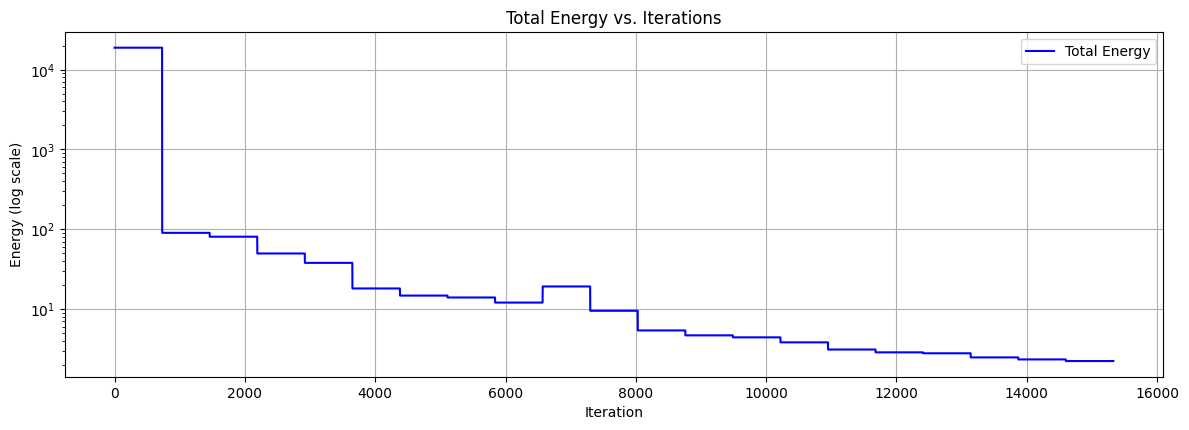

In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import random

class BoltzmannSudokuSolverWithVisualization:
    def __init__(self, temperature=1.0):
        self.temperature = temperature
        self.n = 9
        self.energy_history = []

    def generate_puzzle(self):
        """Generate a random Sudoku puzzle"""
        # Initialize empty 9x9 grid
        grid = np.zeros((9, 9), dtype=int)

        # Fill diagonal 3x3 boxes with random numbers
        for i in range(0, 9, 3):
            nums = list(range(1, 10))
            random.shuffle(nums)
            for j in range(3):
                for k in range(3):
                    grid[i + j][i + k] = nums.pop()

        # Solve the grid
        self._solve_basic(grid)

        # Remove some numbers to create puzzle
        puzzle = grid.copy()
        for _ in range(40):  # Remove 40 numbers
            row = random.randint(0, 8)
            col = random.randint(0, 8)
            puzzle[row][col] = 0

        return puzzle, grid

    def _solve_basic(self, grid):
        """Helper method to solve Sudoku using backtracking"""
        find = self._find_empty(grid)
        if not find:
            return True

        row, col = find
        for num in range(1, 10):
            if self._valid(grid, num, (row, col)):
                grid[row][col] = num

                if self._solve_basic(grid):
                    return True

                grid[row][col] = 0

        return False

    def _find_empty(self, grid):
        """Find empty cell in grid"""
        for i in range(9):
            for j in range(9):
                if grid[i][j] == 0:
                    return (i, j)
        return None

    def _valid(self, grid, num, pos):
        """Check if number is valid in position"""
        # Check row
        for j in range(9):
            if grid[pos[0]][j] == num and pos[1] != j:
                return False

        # Check column
        for i in range(9):
            if grid[i][pos[1]] == num and pos[0] != i:
                return False

        # Check 3x3 box
        box_x = pos[1] // 3
        box_y = pos[0] // 3
        for i in range(box_y * 3, box_y * 3 + 3):
            for j in range(box_x * 3, box_x * 3 + 3):
                if grid[i][j] == num and (i, j) != pos:
                    return False

        return True

    def to_binary(self, grid):
        """Convert Sudoku grid to binary representation"""
        binary = np.zeros((self.n, self.n, self.n))
        for i in range(self.n):
            for j in range(self.n):
                if grid[i][j] != 0:
                    binary[i][j][grid[i][j]-1] = 1
        return binary.flatten()

    def from_binary(self, binary):
        """Convert binary representation back to Sudoku grid"""
        binary = binary.reshape((self.n, self.n, self.n))
        grid = np.zeros((self.n, self.n), dtype=int)
        for i in range(self.n):
            for j in range(self.n):
                if np.sum(binary[i][j]) > 0:
                    grid[i][j] = np.argmax(binary[i][j]) + 1
        return grid

    def energy(self, state, puzzle):
        """Calculate energy (cost) of current state"""
        state = state.reshape((self.n, self.n, self.n))
        energy = 0

        # Row constraints
        row_energy = np.sum((np.sum(state, axis=1) - 1) ** 2)
        energy += row_energy

        # Column constraints
        col_energy = np.sum((np.sum(state, axis=0) - 1) ** 2)
        energy += col_energy

        # Box constraints
        box_energy = 0
        for box_i in range(3):
            for box_j in range(3):
                box = state[box_i*3:(box_i+1)*3, box_j*3:(box_j+1)*3]
                box_energy += np.sum((np.sum(box.reshape(-1, 9), axis=0) - 1) ** 2)
        energy += box_energy

        # Fixed numbers constraints
        puzzle_binary = self.to_binary(puzzle)
        fixed_energy = 1000 * np.sum((state.flatten() - puzzle_binary) ** 2 * (puzzle_binary > 0))
        energy += fixed_energy

        # Store energy components for visualization
        self.energy_history.append({
            'total': energy,
            'row': row_energy,
            'column': col_energy,
            'box': box_energy,
            'fixed': fixed_energy
        })

        return energy

    def solve(self, puzzle):
        """Solve Sudoku using Boltzmann machine concepts"""
        self.energy_history = []  # Reset energy history

        # Initialize with random state
        initial_state = np.random.random(self.n * self.n * self.n)

        # Define bounds for variables (between 0 and 1)
        bounds = [(0, 1) for _ in range(self.n * self.n * self.n)]

        # Minimize energy function
        result = minimize(
            lambda x: self.energy(x, puzzle),
            initial_state,
            method='L-BFGS-B',
            bounds=bounds
        )

        # Convert result back to Sudoku grid
        solution = self.from_binary(result.x)
        return solution

    def plot_energy_history(self):
        """Plot the energy history during optimization"""
        plt.figure(figsize=(12, 8))

        # Extract energy components
        iterations = range(len(self.energy_history))
        total_energy = [e['total'] for e in self.energy_history]
        row_energy = [e['row'] for e in self.energy_history]
        col_energy = [e['column'] for e in self.energy_history]
        box_energy = [e['box'] for e in self.energy_history]
        fixed_energy = [e['fixed'] for e in self.energy_history]

        # Plot total energy
        plt.subplot(2, 1, 1)
        plt.plot(iterations, total_energy, 'b-', label='Total Energy')
        plt.yscale('log')
        plt.title('Total Energy vs. Iterations')
        plt.xlabel('Iteration')
        plt.ylabel('Energy (log scale)')
        plt.grid(True)
        plt.legend()



        plt.tight_layout()
        return plt.gcf()  # Return the figure for display

# Example usage
solver = BoltzmannSudokuSolverWithVisualization()

# Generate a puzzle
puzzle, solution = solver.generate_puzzle()

print("Generated Puzzle:")
print(puzzle)
print("\nOriginal Solution:")
print(solution)

# Solve and get energy visualization
print("\nSolving...")
solved = solver.solve(puzzle)
print("\nSolved using Boltzmann machine concepts:")
print(solved)

# Plot energy history
fig = solver.plot_energy_history()
plt.show()

## Discussion Questions (10 mins):

1. *Conceptual Understanding*. (5 mins)  
In CSP-based Sudoku solving, constraints are strictly deterministic — each number must satisfy row, column, and subgrid constraints.   
Compare this deterministic approach with the probabilistic reasoning used in neural networks and causal nets. What are the **core differences** in how these methods handle uncertainty and solution space exploration?   
In addition, what are the advantages and disadvantages of relying on **hard constraints** in CSPs versus the **soft constraints** that can be modeled by neural networks or causal nets?
   
2. *Application and Analysis*. (5 mins)  
In constraint propagation for CSPs, values are eliminated from the possible options for a cell based on the Sudoku constraints (row, column, subgrid). If you were to implement a more **relaxed** version of constraint propagation that allows for temporary violations of these constraints (e.g., softening constraints), how would this change the solution process? What trade-offs would you face in terms of:
 *   **Completeness** (always finding a solution if one exists)
 *   **Efficiency** (solving speed)
 *   **Accuracy** (avoiding mistakes)  
   
 How does this idea of **softening constraints** relate to the heuristic search techniques like backtracking used in CSPs?

# Search (10 mins)

In [ ]:
import time
from copy import deepcopy

def cross(A, B):
    "Cross product of elements in A and elements in B."
    return [a+b for a in A for b in B]

digits   = '123456789'
rows     = 'ABCDEFGHI'
cols     = digits
squares  = cross(rows, cols)
unitlist = ([cross(rows, c) for c in cols] +
            [cross(r, cols) for r in rows] +
            [cross(rs, cs) for rs in ('ABC','DEF','GHI') for cs in ('123','456','789')])
units = dict((s, [u for u in unitlist if s in u])
             for s in squares)
peers = dict((s, set(sum(units[s],[]))-set([s]))
             for s in squares)

class Colors:
    RED = '\033[91m'
    RESET = '\033[0m'

def parse_grid(grid):
    """Convert grid to a dict of possible values, {square: digits}, or
    return False if a contradiction is detected."""
    values = dict((s, digits) for s in squares)
    for s,d in grid_values(grid).items():
        if d in digits and not assign(values, s, d):
            return False
    return values

def grid_values(grid):
    "Convert grid into a dict of {square: char} with '0' or '.' for empties."
    chars = [c for c in grid if c in digits or c in '0.']
    return dict(zip(squares, chars))

def assign(values, s, d):
    """Eliminate all the other values (except d) from values[s] and propagate."""
    other_values = values[s].replace(d, '')
    if all(eliminate(values, s, d2) for d2 in other_values):
        return values
    else:
        return False

def eliminate(values, s, d):
    """Eliminate d from values[s]; propagate when values or places <= 2."""
    if d not in values[s]:
        return values
    values[s] = values[s].replace(d,'')
    if len(values[s]) == 0:
        return False
    elif len(values[s]) == 1:
        d2 = values[s]
        if not all(eliminate(values, s2, d2) for s2 in peers[s]):
            return False
    for u in units[s]:
        dplaces = [s for s in u if d in values[s]]
        if len(dplaces) == 0:
            return False
        elif len(dplaces) == 1:
            if not assign(values, dplaces[0], d):
                return False
    return values

def search(values):
    """Using depth-first search and propagation, try all possible values.
    Returns (solution, steps) where steps is a list of grid states."""
    steps = []

    def search_with_steps(values):
        if values is False:
            return False
        if all(len(values[s]) == 1 for s in squares):
            return values
        n,s = min((len(values[s]), s) for s in squares if len(values[s]) > 1)

        for d in values[s]:
            new_values = assign(values.copy(), s, d)
            if new_values:
                steps.append(deepcopy(new_values))  # Store each step
                result = search_with_steps(new_values)
                if result:
                    return result
        return False

    solution = search_with_steps(values)
    return solution, steps

def display(values, previous_values=None):
    """Display these values as a 2-D grid with changes highlighted in red."""
    if not values:
        print('No solution exists')
        return

    width = 1+max(len(values[s]) for s in squares)
    line = '+'.join(['-'*(width*3)]*3)

    for r in rows:
        for c in cols:
            square = r+c
            value = values[square]

            # Determine if this value has changed
            changed = (previous_values and
                      square in previous_values and
                      value != previous_values[square])

            # Format the value with color if changed
            if changed:
                cell = Colors.RED + value.center(width) + Colors.RESET
            else:
                cell = value.center(width)

            # Add separators
            if c in '36':
                cell += '|'
            print(cell, end='')
        print()
        if r in 'CF':
            print(line)
    print()

def solve_with_visualization(grid, delay=0.5):
    """Solve the Sudoku puzzle and show each step."""
    print("Initial grid:")
    initial_values = grid_values(grid)
    display(initial_values)
    print("\nSolving...\n")

    values = parse_grid(grid)
    if not values:
        print("Cannot parse grid")
        return

    solution, steps = search(values)

    # Display each step with highlighting
    previous_values = initial_values
    for i, current_values in enumerate(steps):
        print(f"Step {i + 1}:")
        display(current_values, previous_values)
        previous_values = current_values
        time.sleep(delay)  # Add delay between steps

    if solution:
        print("\nFinal solution:")
        display(solution)
        return solution
    else:
        print("No solution exists")
        return False

# Test the solver with a hard puzzle
if __name__ == "__main__":
    hard_puzzle = '4.....8.5.3..........7......2.....6.....8.4......1.......6.3.7.5..2.....1.4......'
    print("Solving hard puzzle with visualization:")
    start = time.time()
    solution = solve_with_visualization(hard_puzzle, delay=0.5)  # 0.5 second delay between steps
    end = time.time()
    print(f"Solved in {end - start:.4f} seconds")

Solving hard puzzle with visualization:
Initial grid:
4 . . |. . . |8 . 5 
. 3 . |. . . |. . . 
. . . |7 . . |. . . 
------+------+------
. 2 . |. . . |. 6 . 
. . . |. 8 . |4 . . 
. . . |. 1 . |. . . 
------+------+------
. . . |6 . 3 |. 7 . 
5 . . |2 . . |. . . 
1 . 4 |. . . |. . . 


Solving...

Step 1:
   4      1679   12679  |  139     2369    269   |   8      1239     5    
 26789     3    1256789 | 14589   24569   245689 | 12679    1249   124679 
  2689    1569   125689 |   7     234569  245689 | 12369   12349   123469 
------------------------+------------------------+------------------------
  3789     2     15789  |  3459   34579    4579  | 13579     6     13789  
  3679   15679   15679  |  359      8     25679  |   4     12359   12379  
 36789     4     56789  |  359      1     25679  | 23579   23589   23789  
------------------------+------------------------+------------------------
   29      8       29   |   6      459      3    |  1259     7      1249  
   5      679     

# Causal Nets (25 mins)
The following implementation approaches Sudoku as a **Bayesian network** where:

1. **Each cell is treated as a random variable**: Each empty cell in the Sudoku grid is considered a random variable that can take values from 1 to 9. Initially, the possible values for an empty cell are equally likely (uniform probability), while filled cells have a fixed probability of 1 for the known value.

2. **The constraints (row, column, box) are represented as conditional probabilities**: The constraints of Sudoku — that no two cells in the same row, column, or subgrid (box) can have the same value — are represented as conditional probabilities. These constraints influence the likelihood of each possible value for an empty cell.

3. **Belief propagation is used to update probabilities across the network**: For each empty cell, the probabilities of possible values are updated iteratively based on the values of the other cells in the same row, column, and box. This process of updating probabilities based on conditional constraints is similar to belief propagation in Bayesian networks. It ensures that each cell's possible values are continuously refined as other cells are filled.

4. **The solution emerges from repeatedly updating beliefs and selecting high-probability values**: The solver repeatedly updates the probability distributions for the empty cells based on the latest information from neighboring cells. If a cell reaches a high enough probability for a particular value (e.g., >0.9 confidence), that value is selected, and the grid is updated. This process continues until no more updates are possible or the grid is fully solved.

Initial grid:
5 3 . | . 7 . | . . . 
6 . . | 1 9 5 | . . . 
. 9 8 | . . . | . 6 . 
---------------------
8 . . | . 6 . | . . 3 
4 . . | 8 . 3 | . . 1 
7 . . | . 2 . | . . 6 
---------------------
. 6 . | . . . | 2 8 . 
. . . | 4 1 9 | . . 5 
. . . | . 8 . | . 7 9 

Solved grid:
5 3 4 | 6 7 8 | 9 1 2 
6 7 2 | 1 9 5 | 3 4 8 
1 9 8 | 3 4 2 | 5 6 7 
---------------------
8 5 9 | 7 6 1 | 4 2 3 
4 2 6 | 8 5 3 | 7 9 1 
7 1 3 | 9 2 4 | 8 5 6 
---------------------
9 6 1 | 5 3 7 | 2 8 4 
2 8 7 | 4 1 9 | 6 3 5 
3 4 5 | 2 8 6 | 1 7 9 


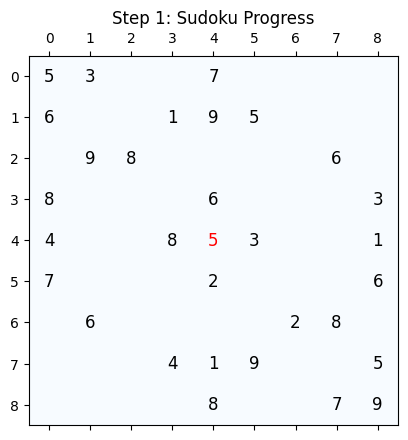

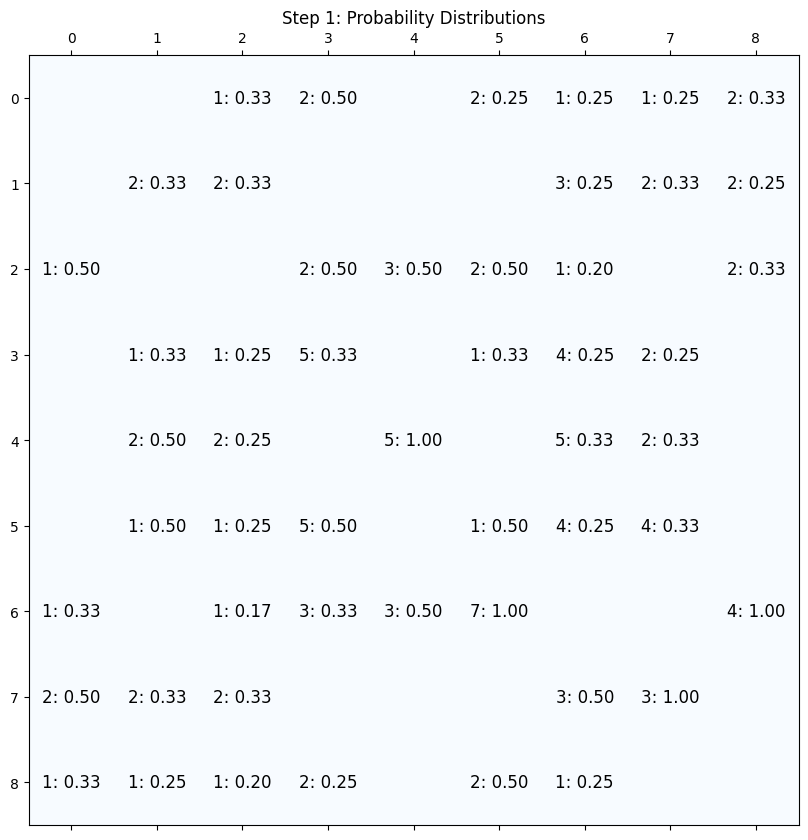

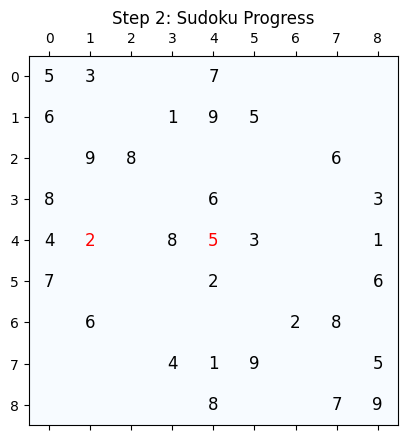

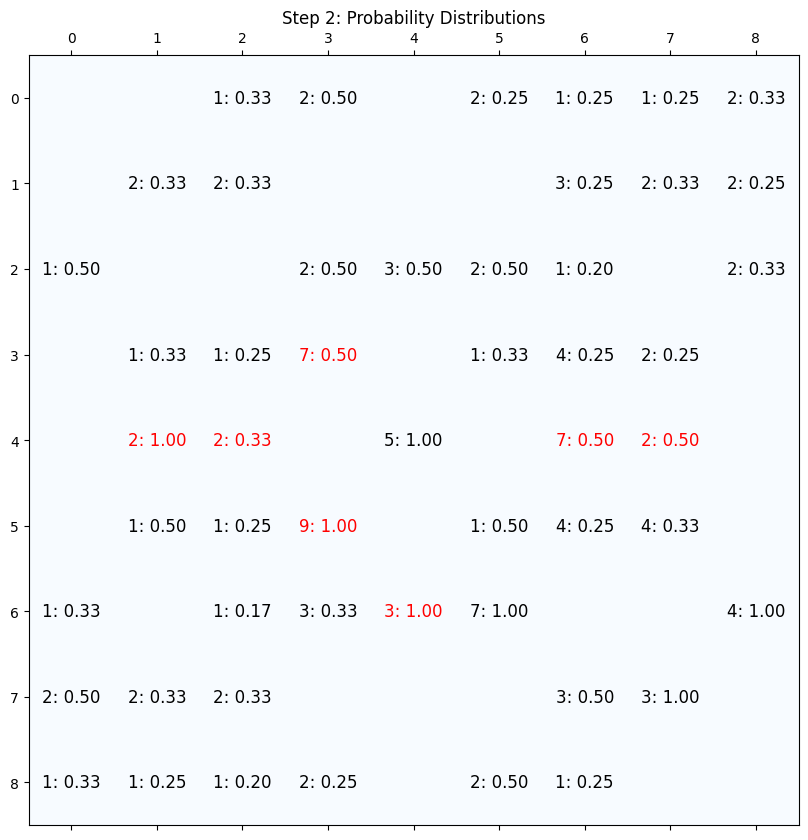

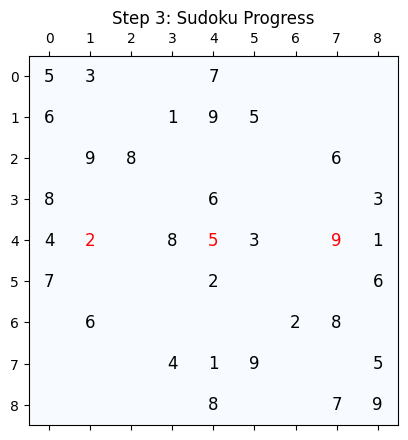

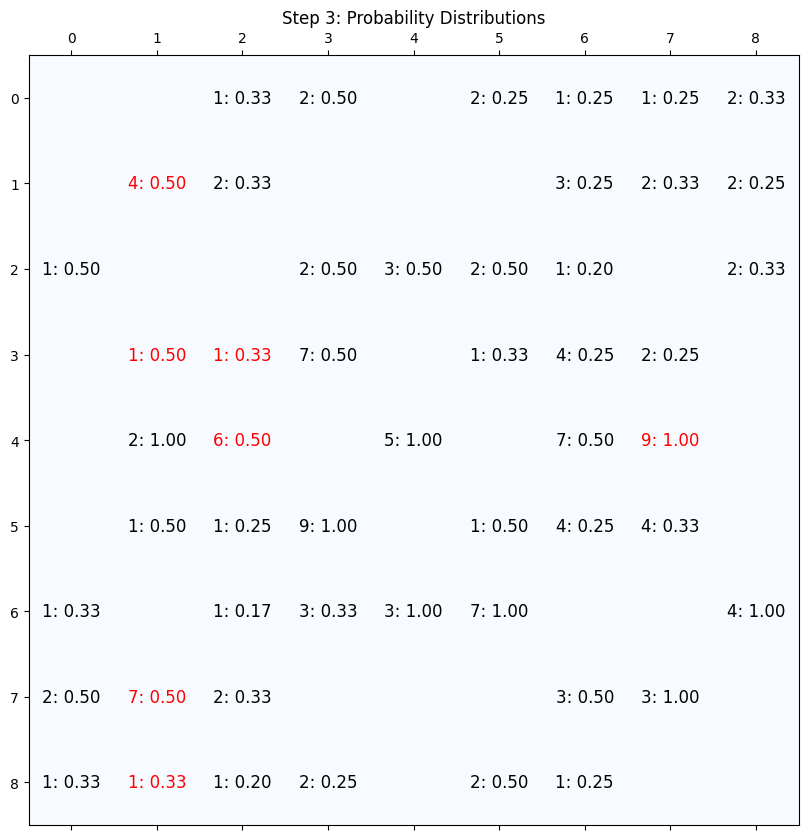

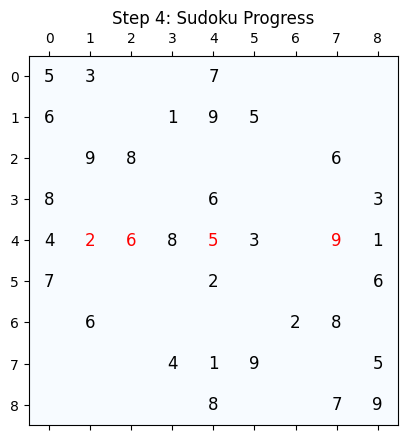

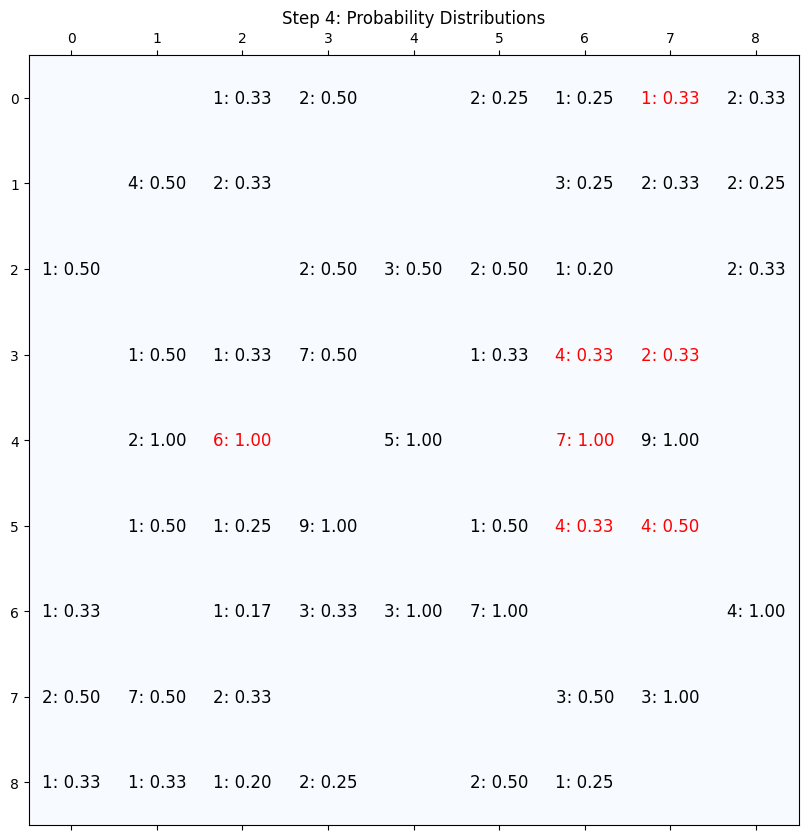

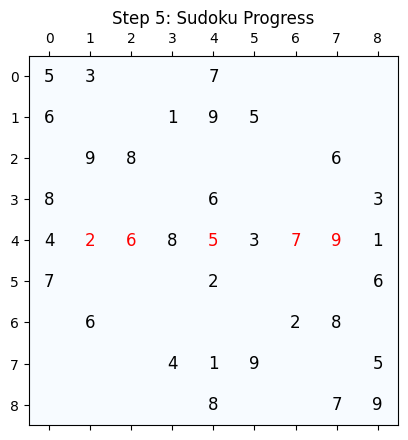

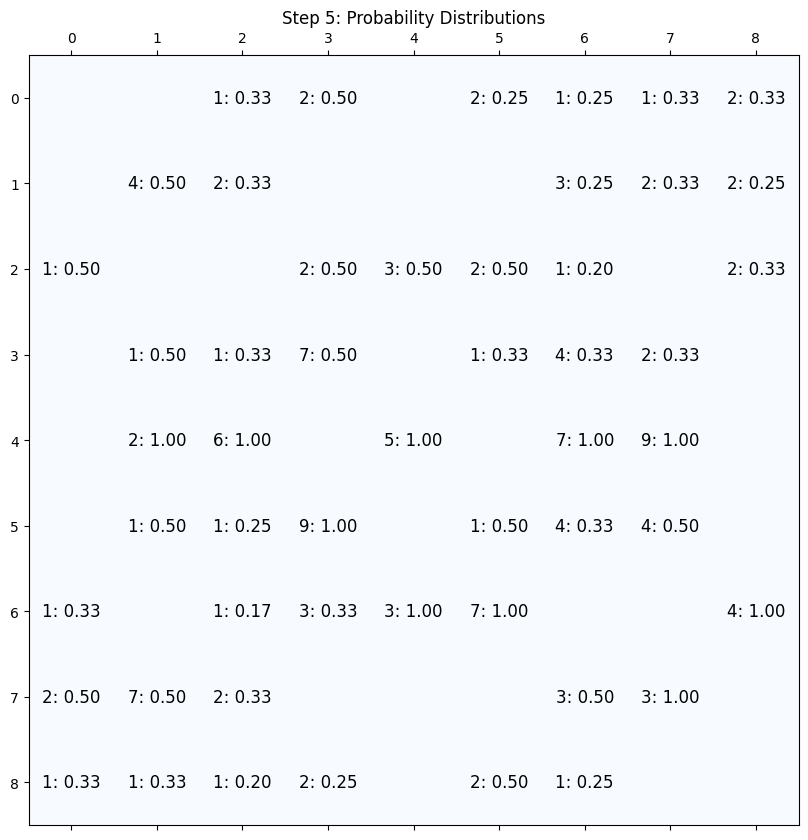

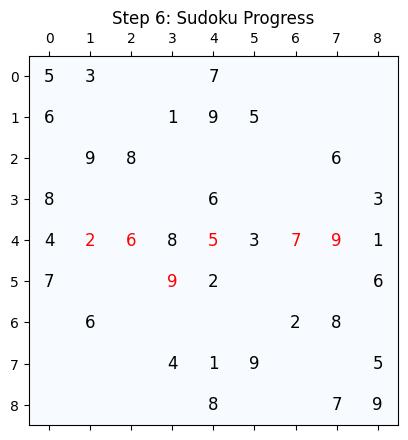

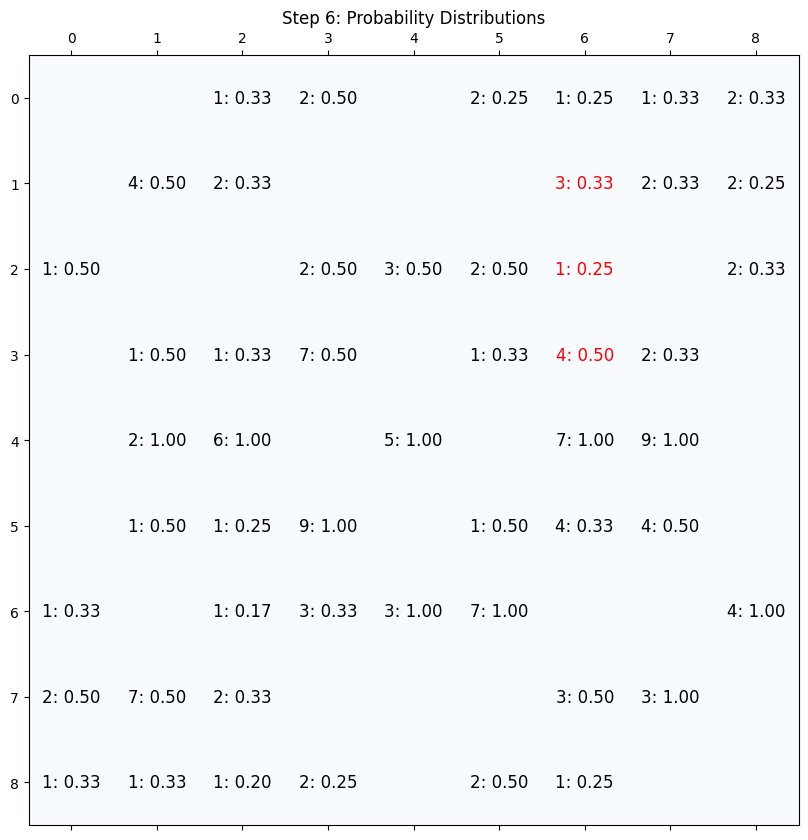

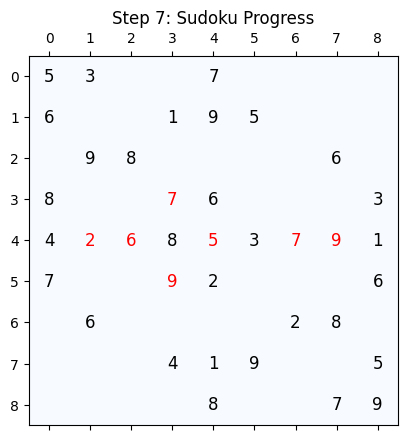

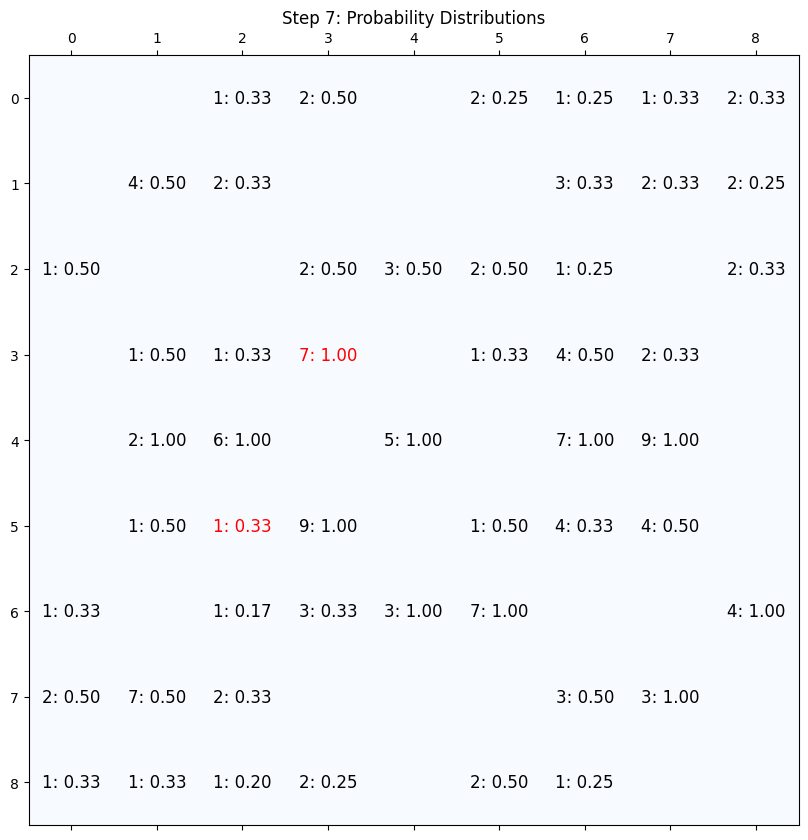

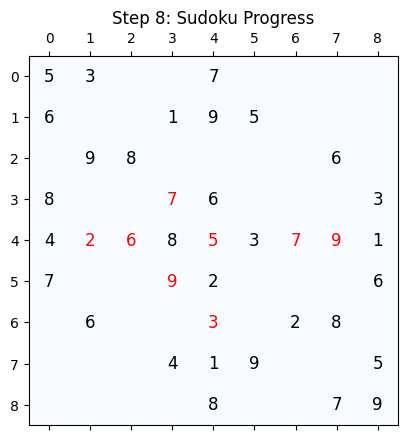

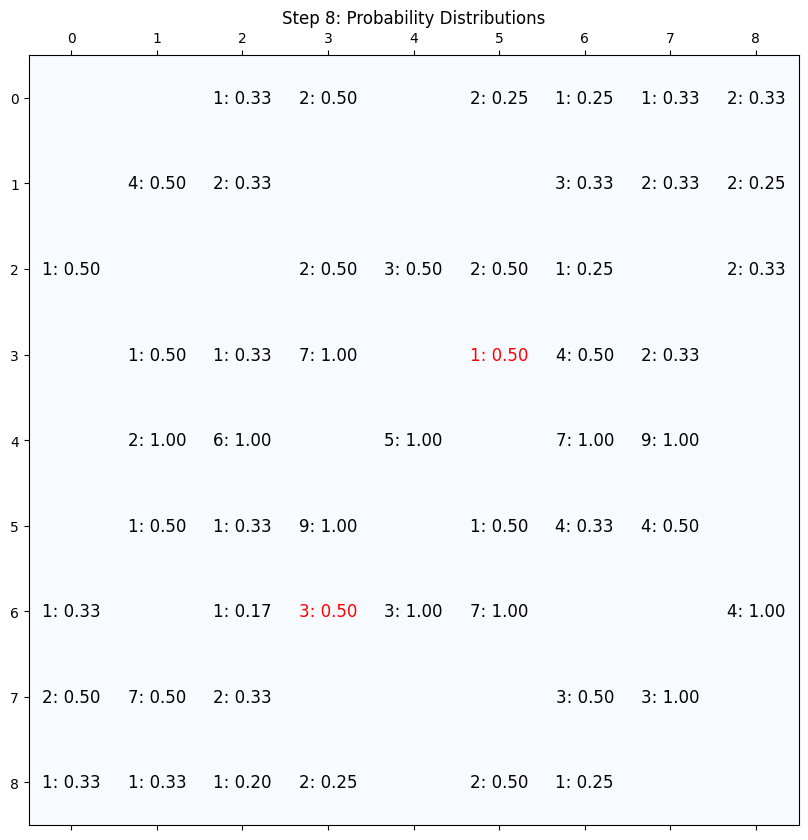

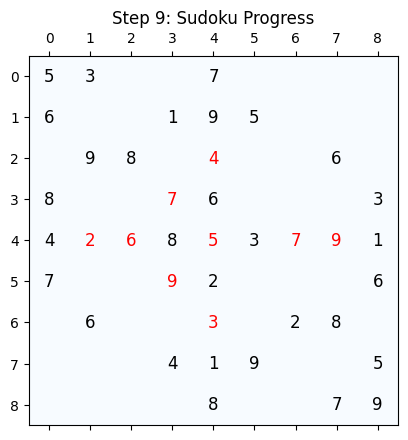

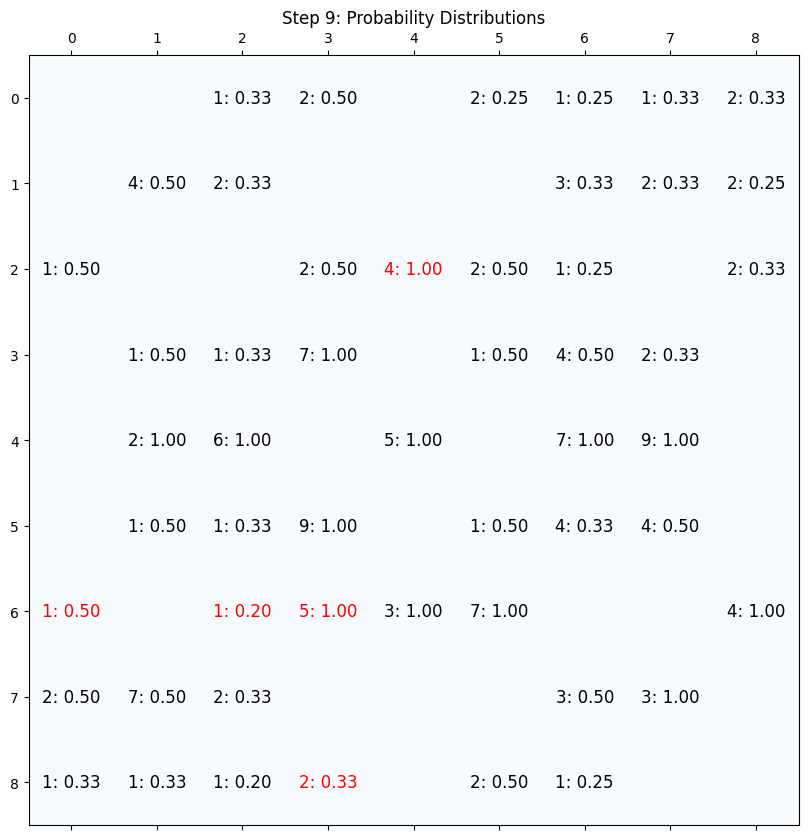

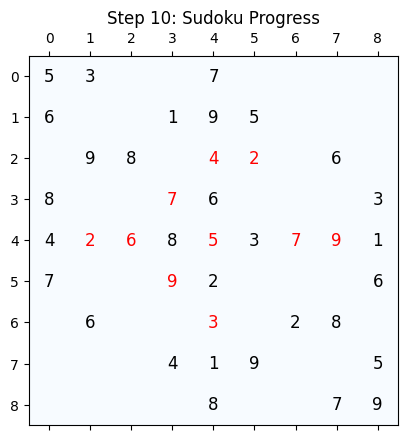

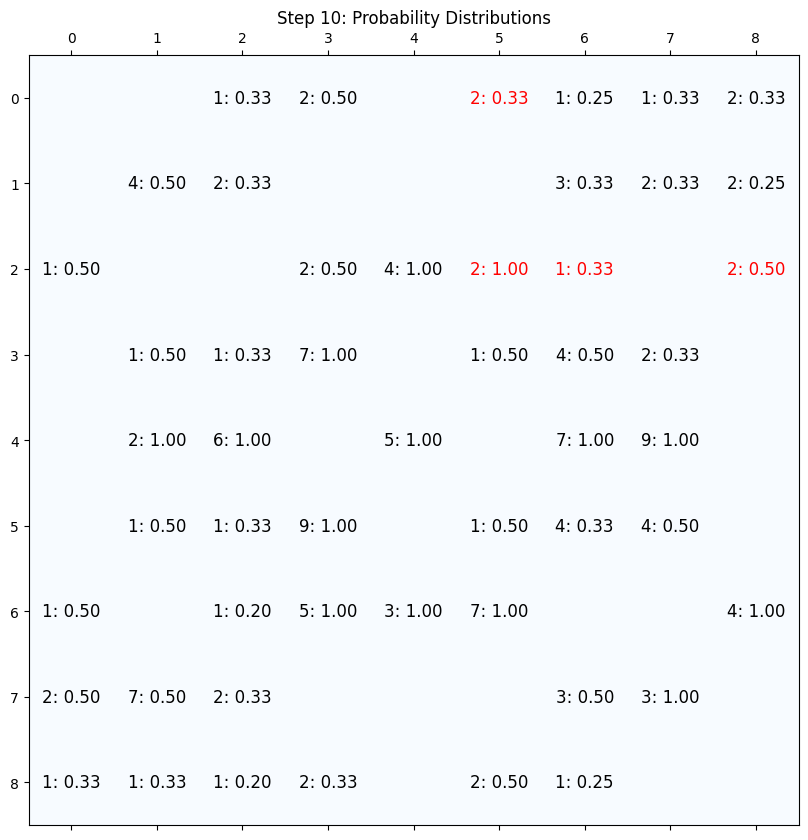

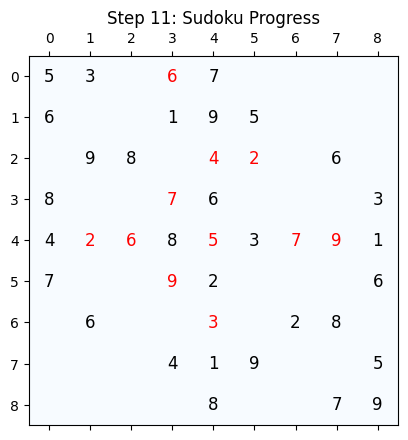

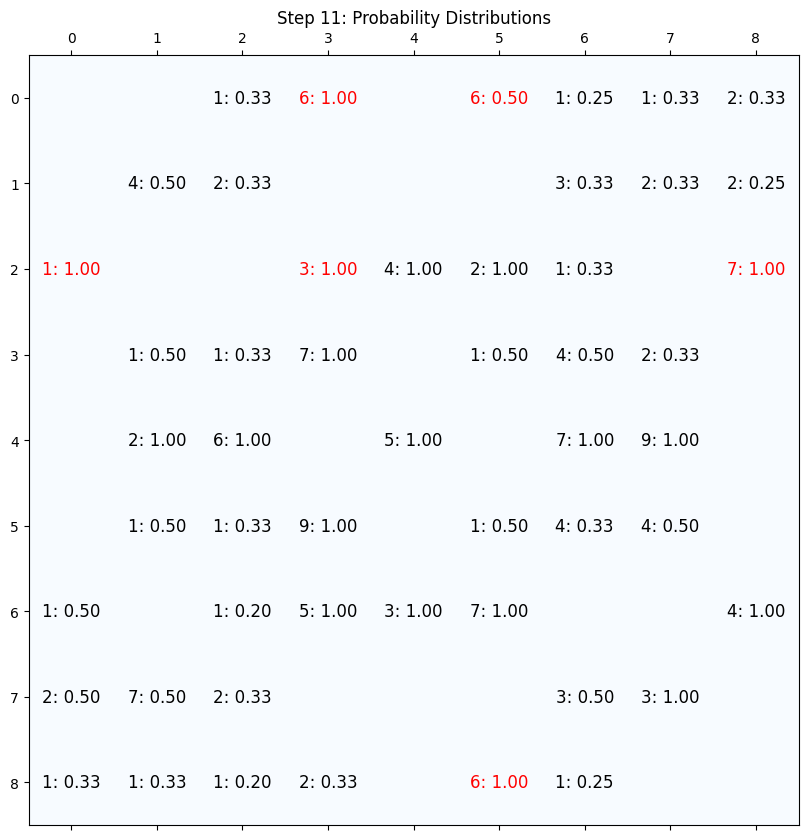

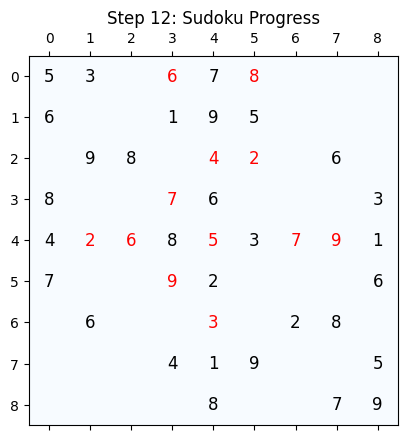

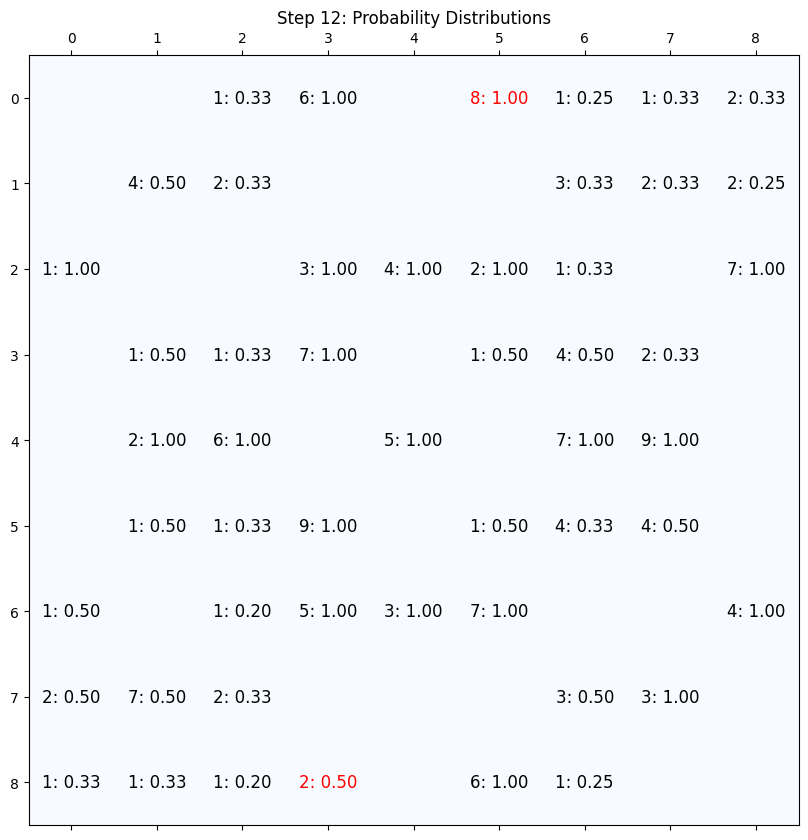

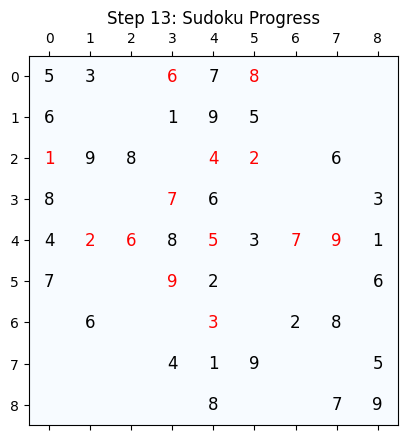

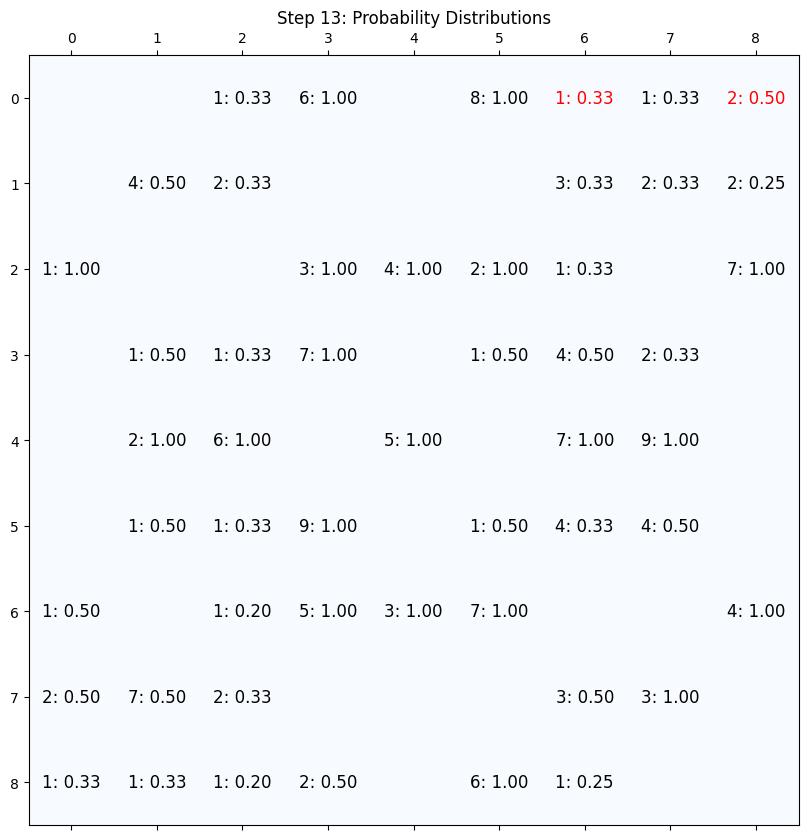

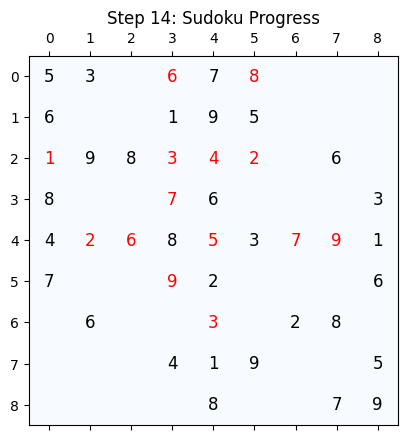

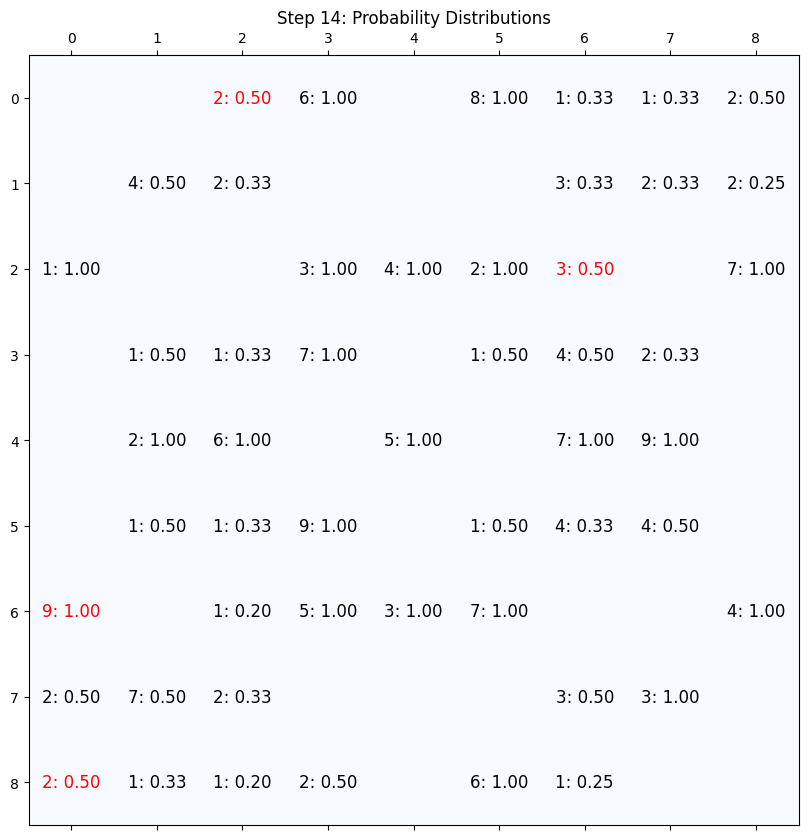

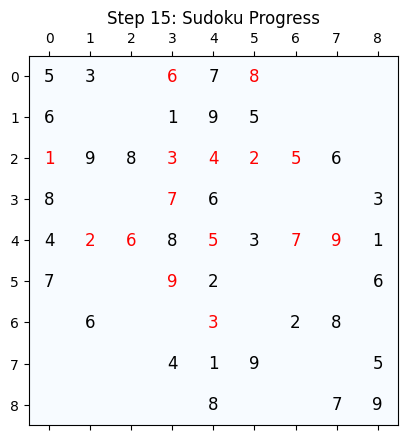

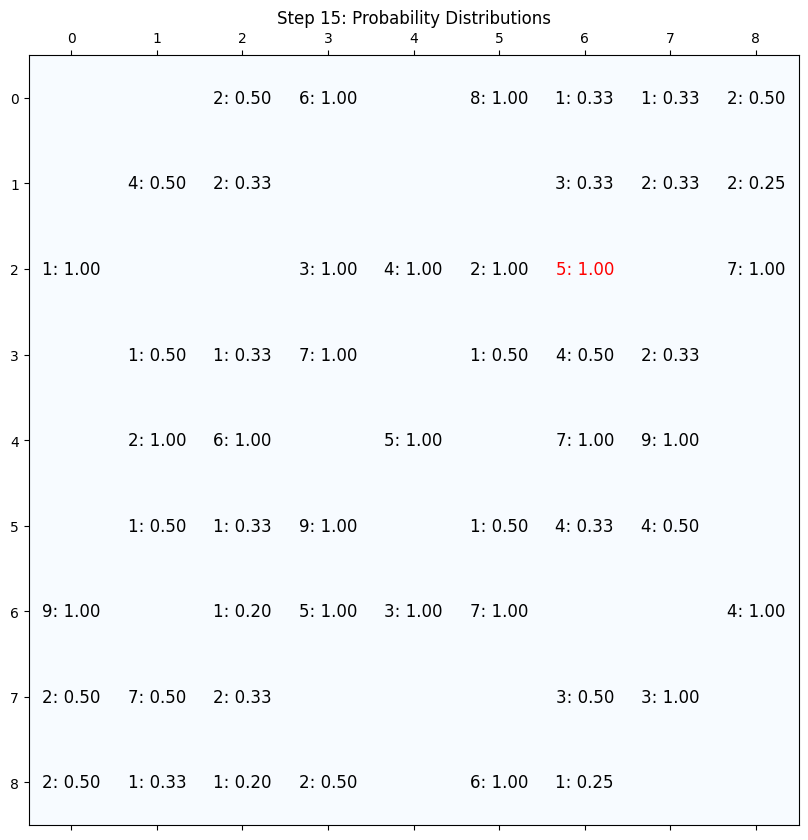

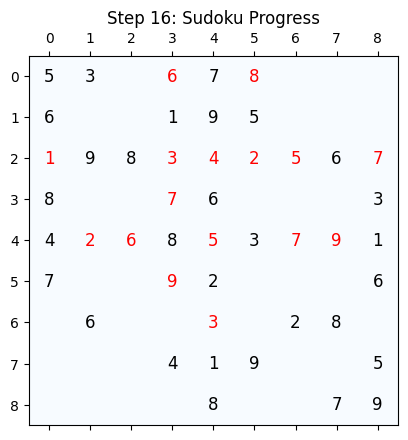

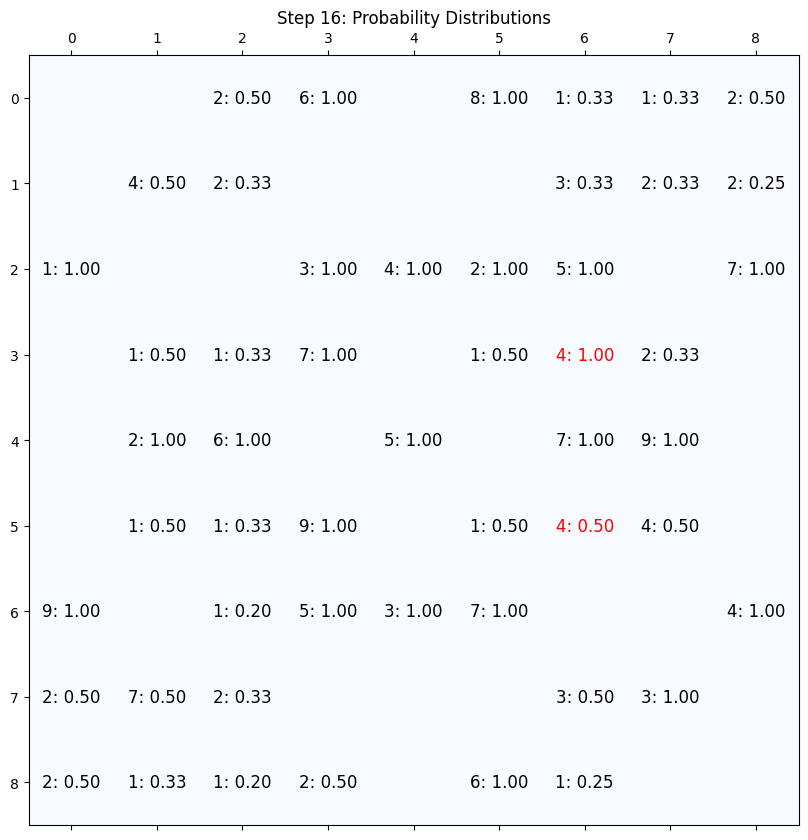

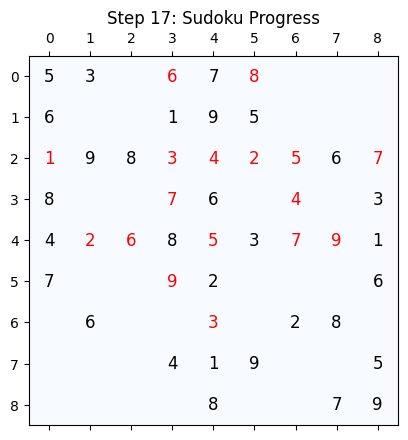

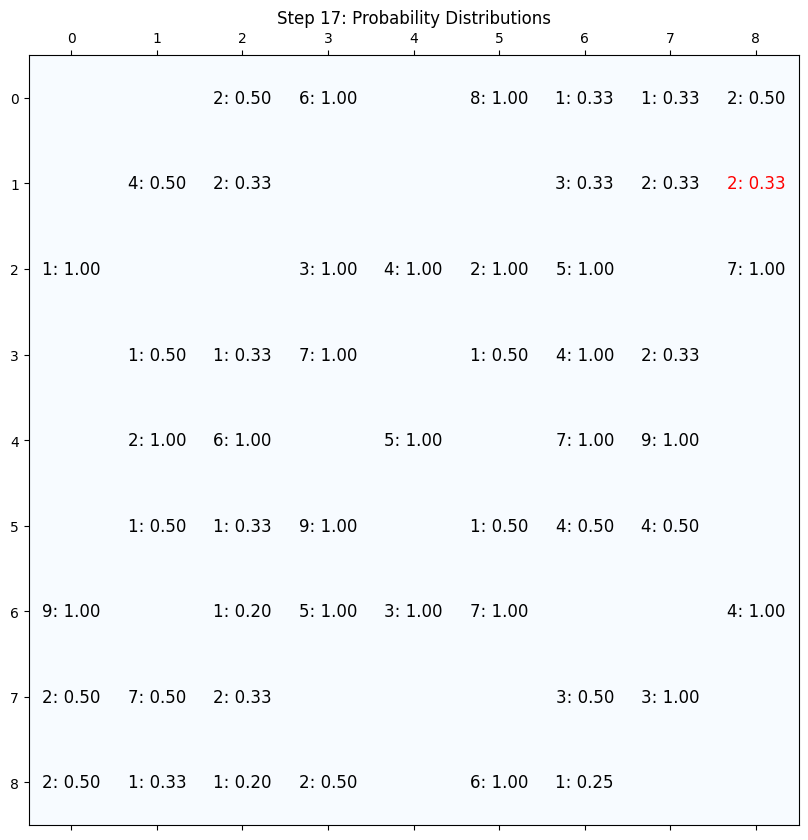

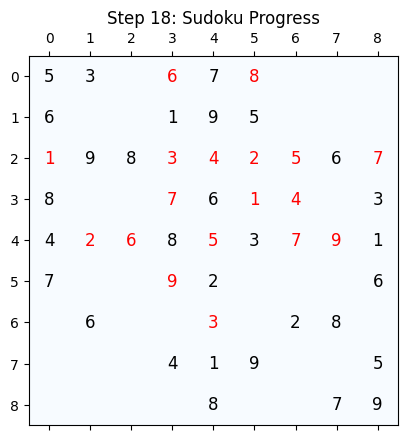

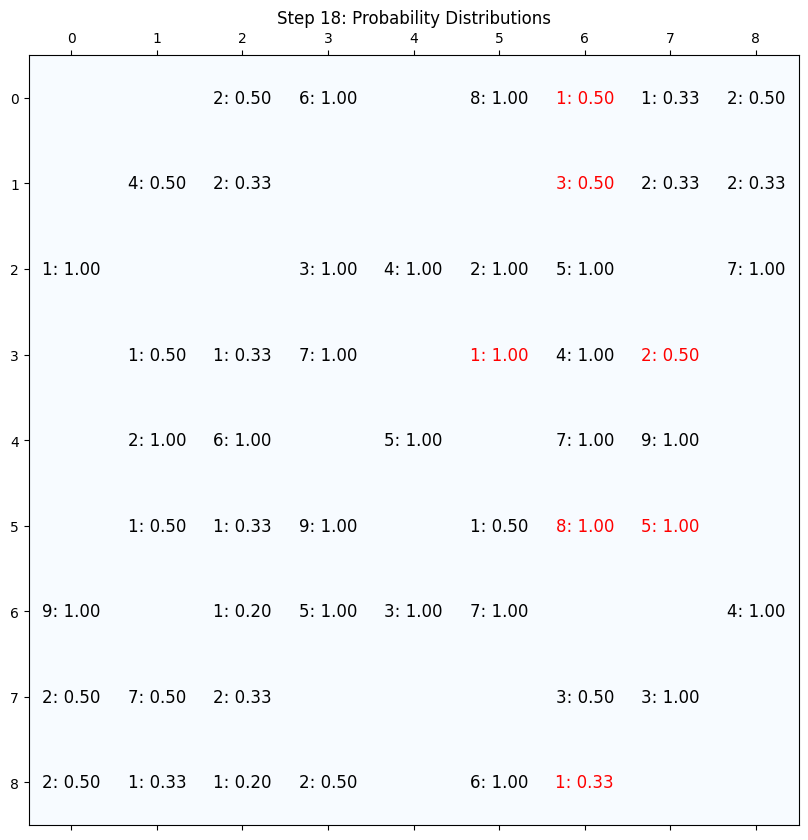

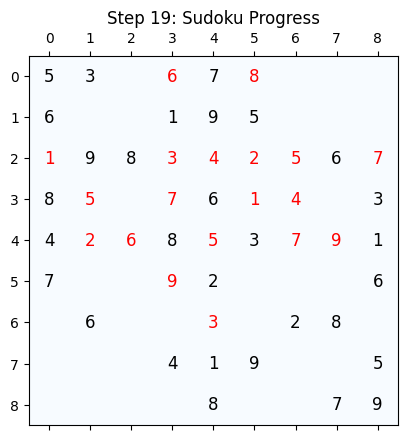

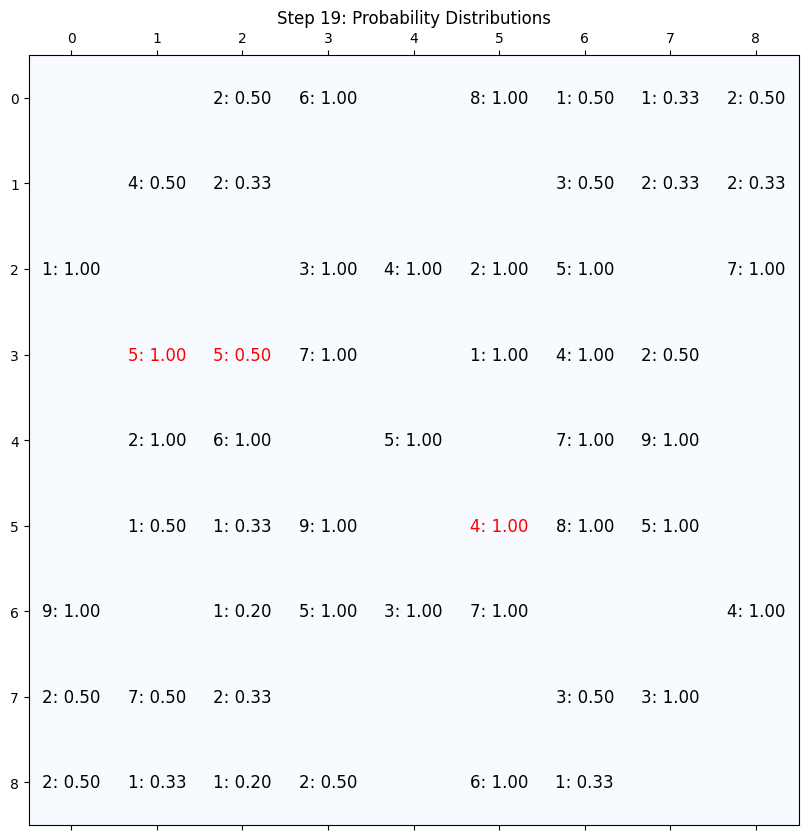

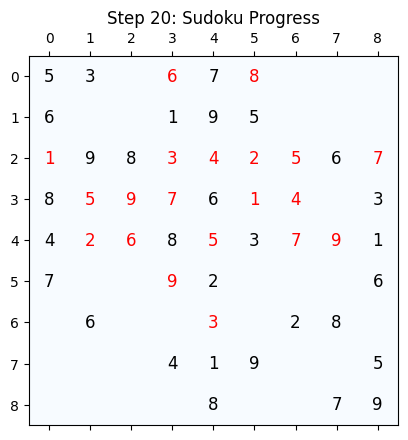

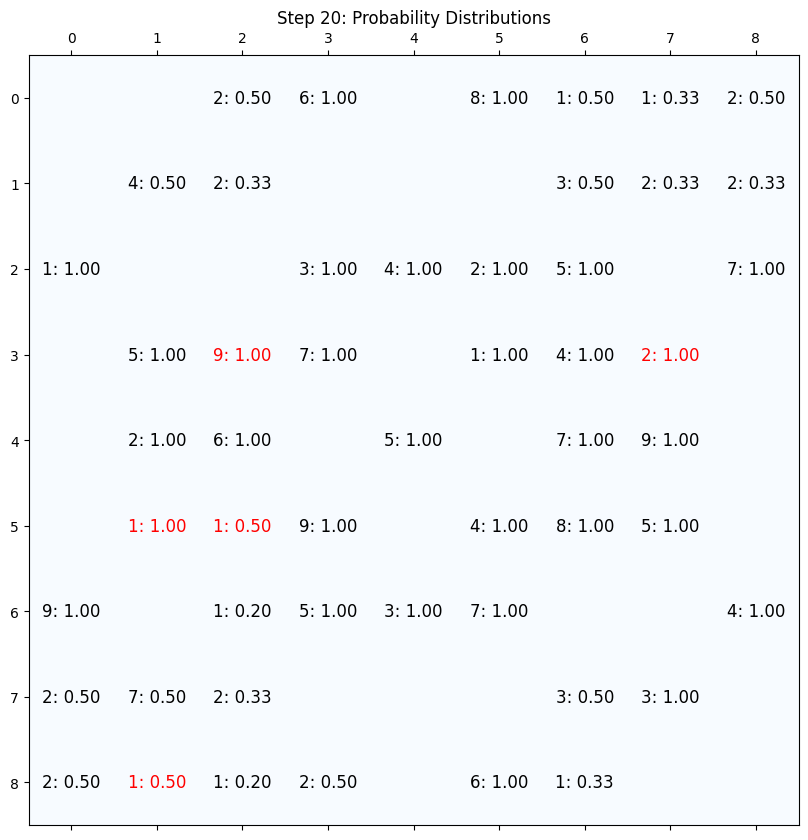

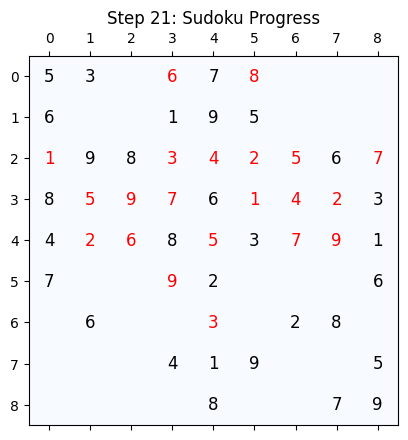

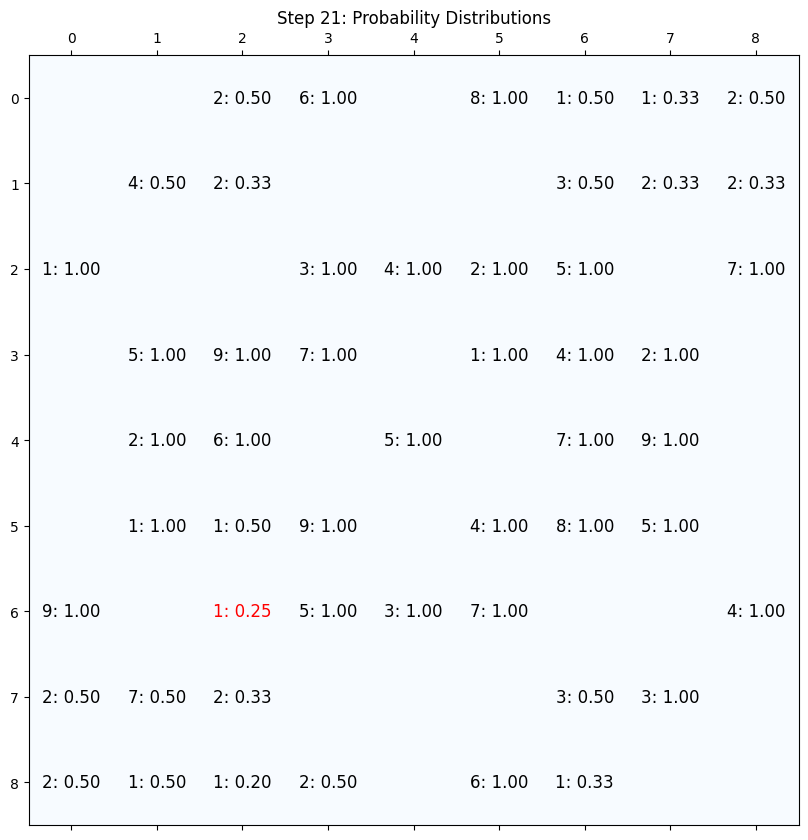

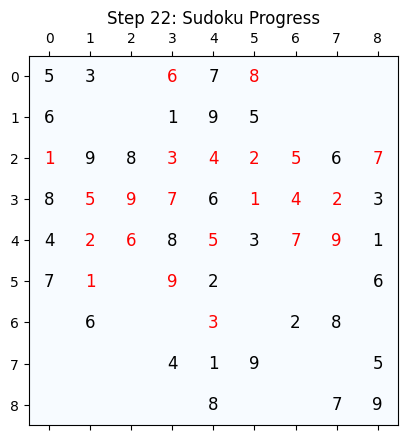

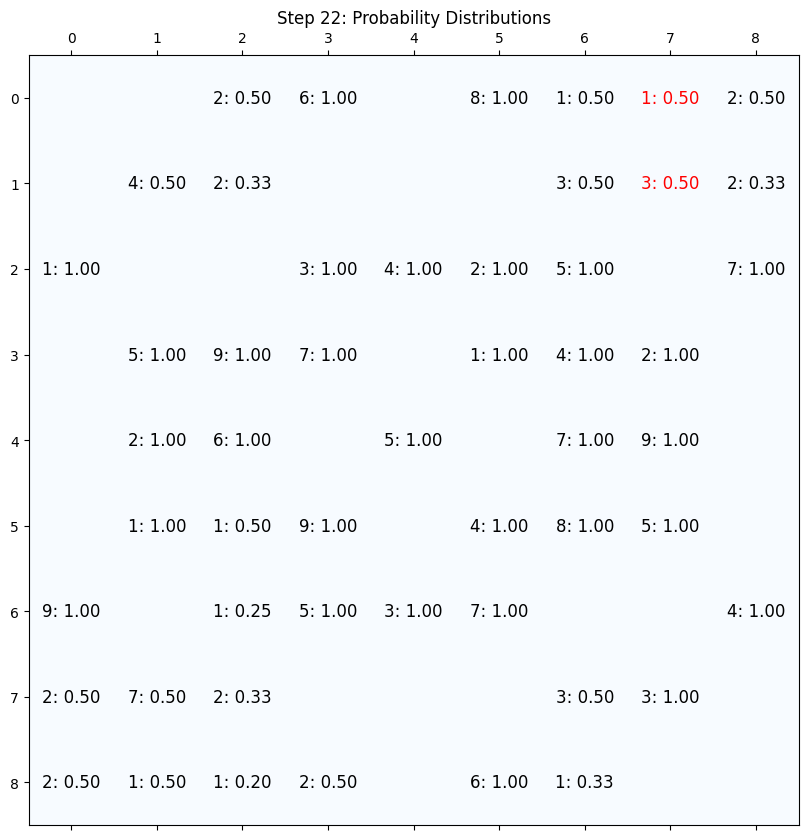

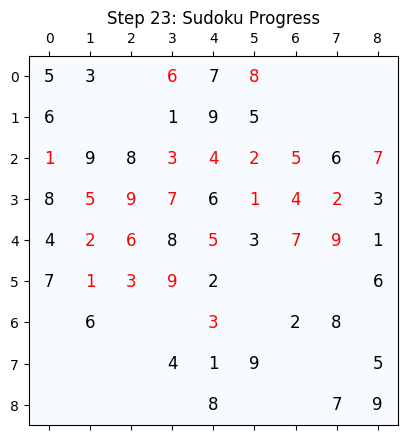

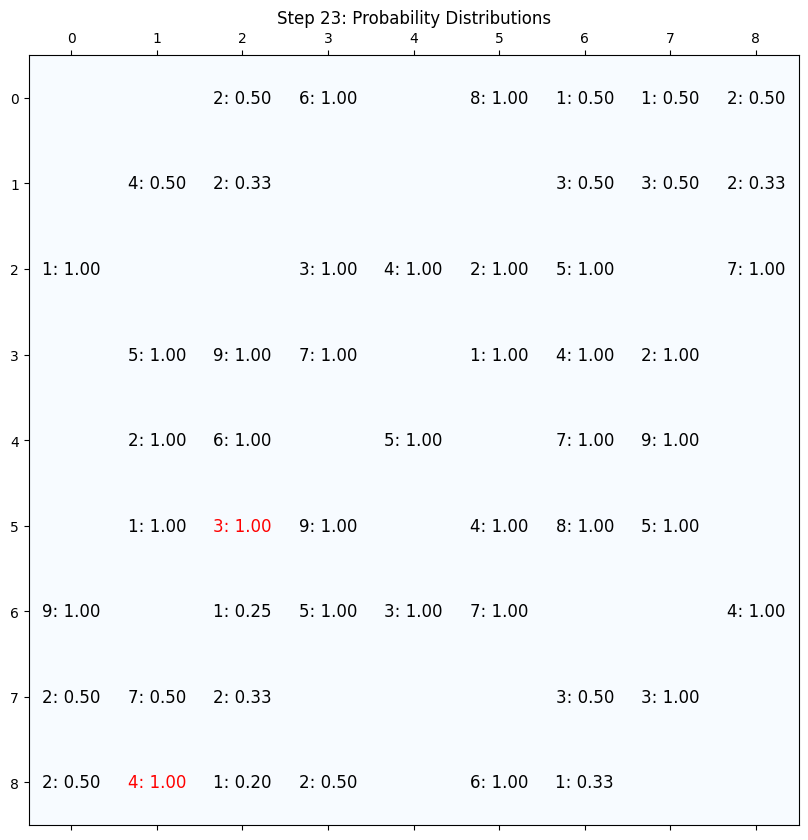

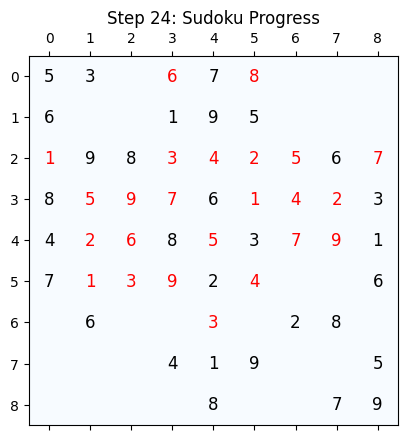

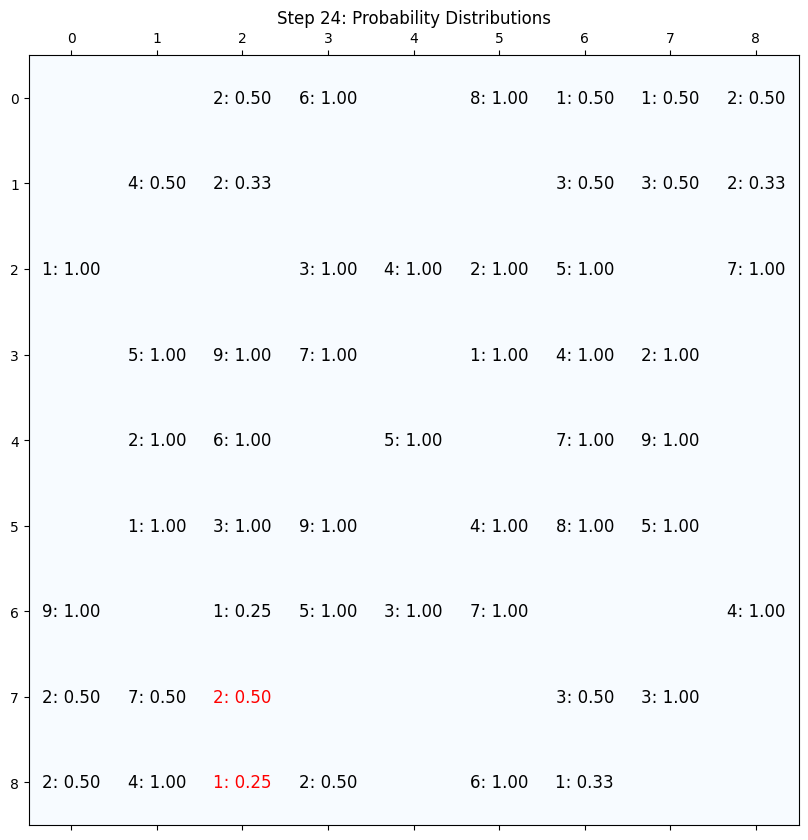

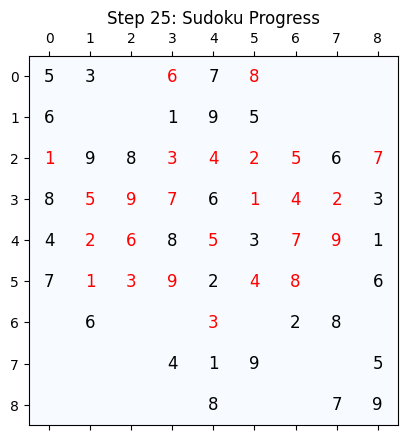

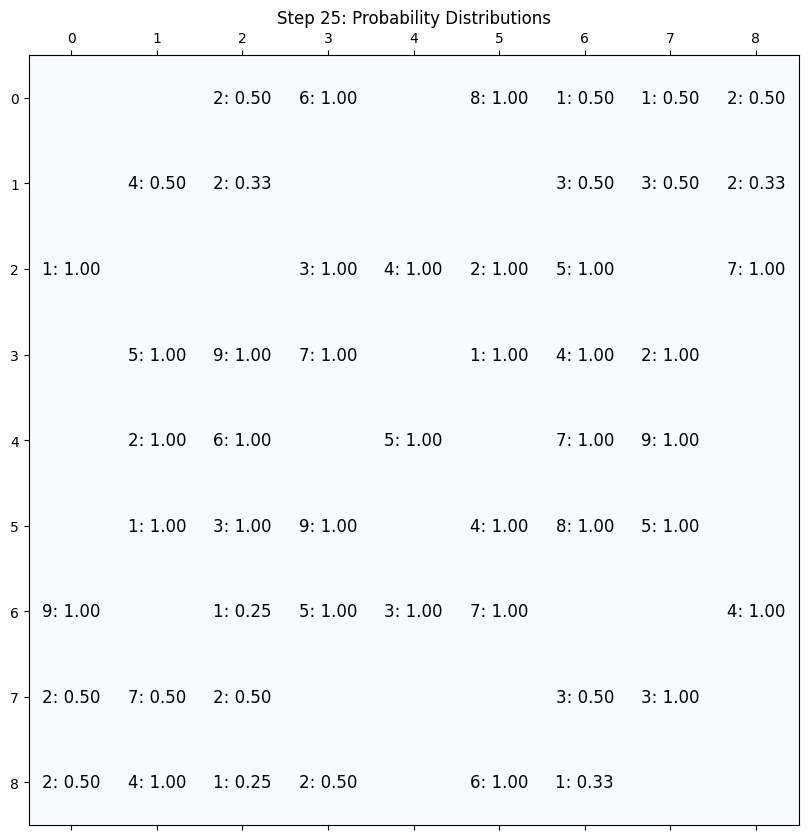

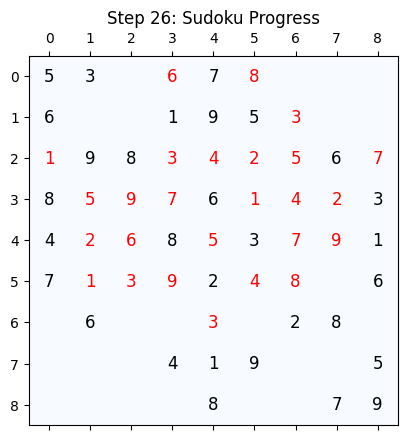

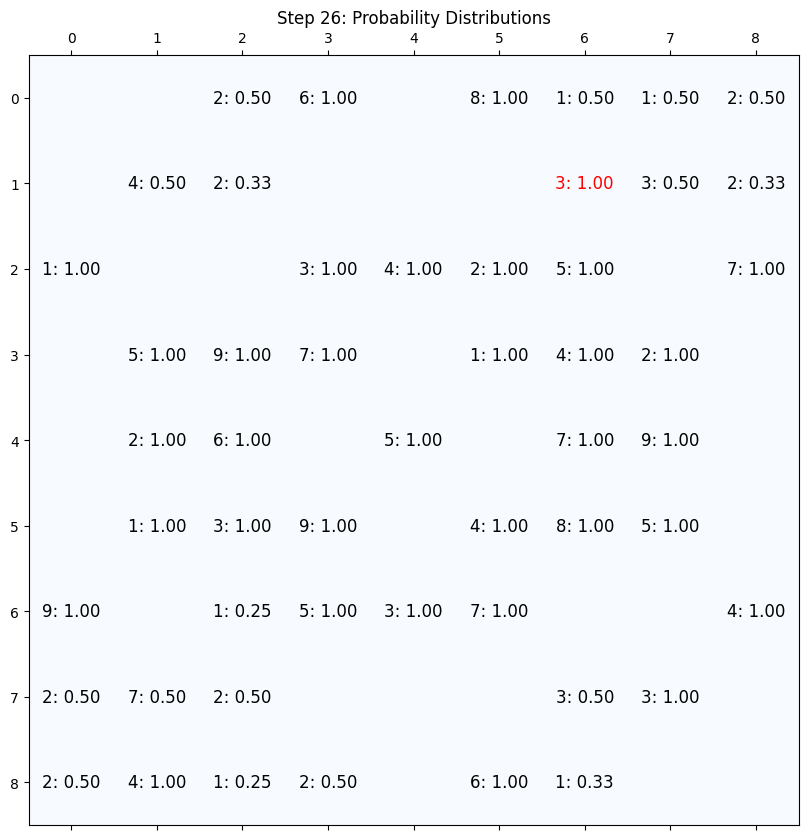

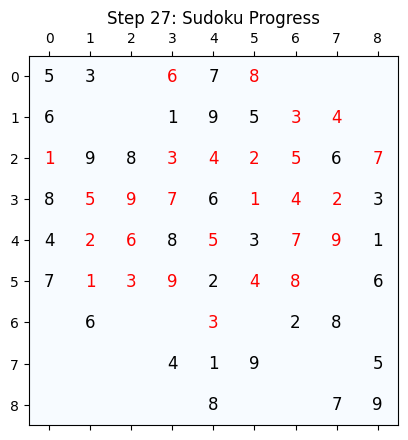

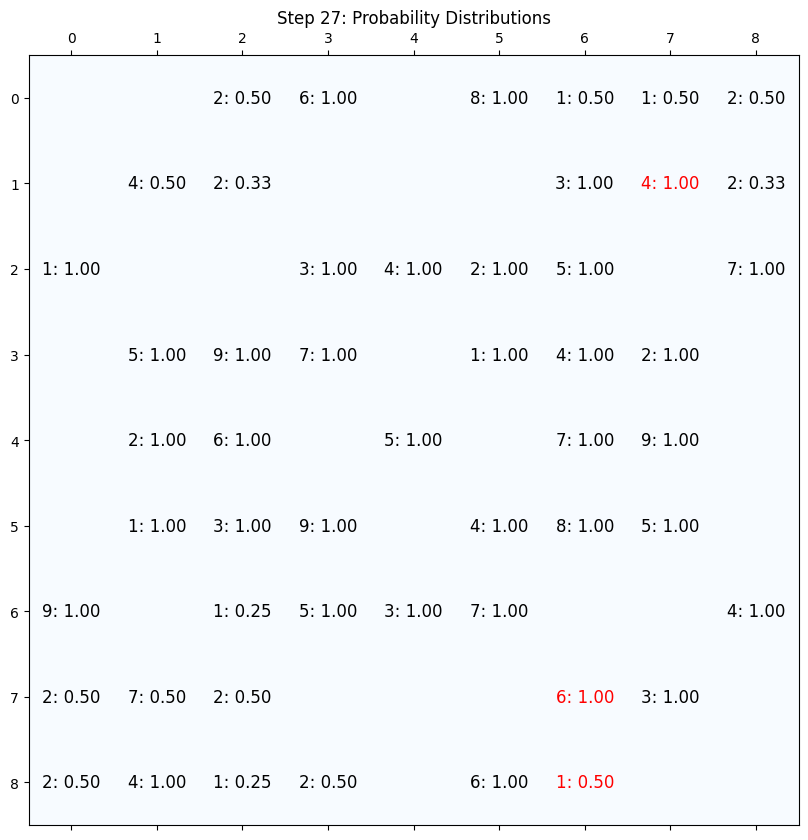

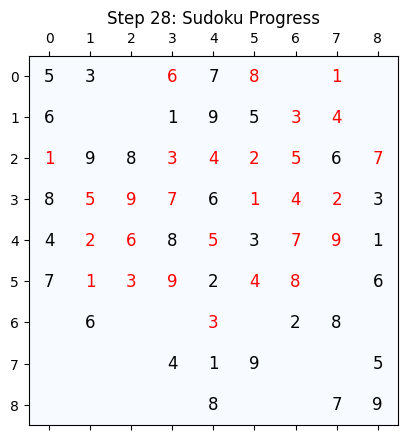

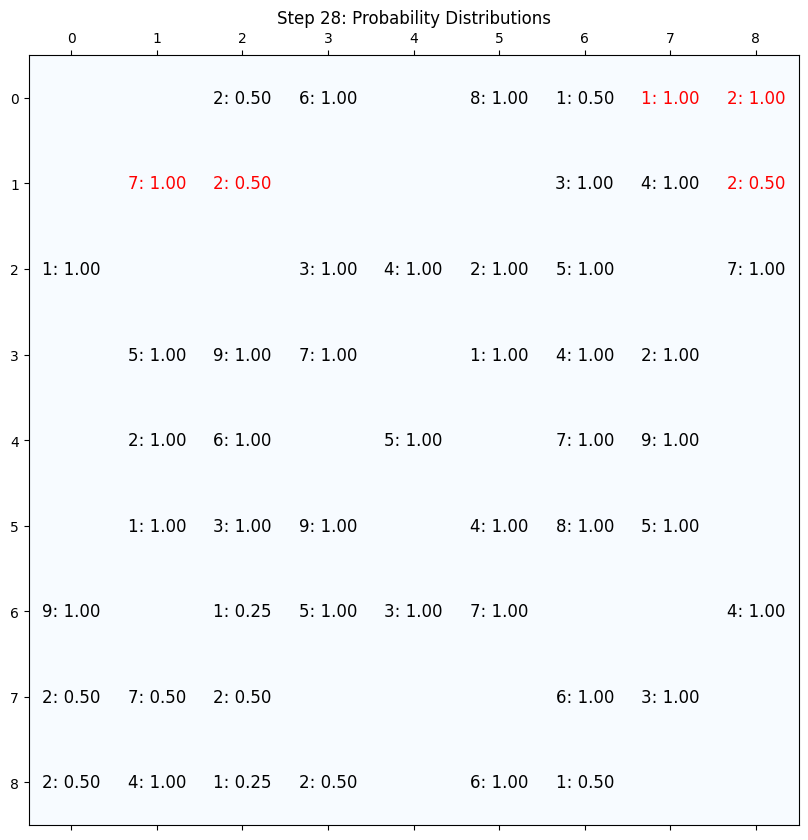

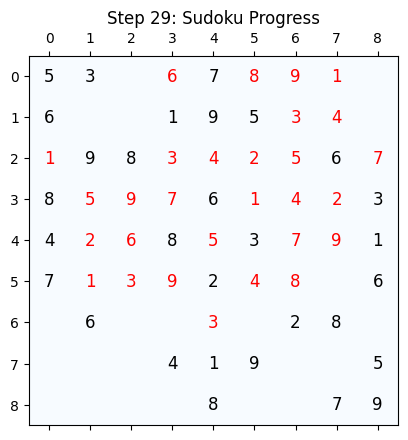

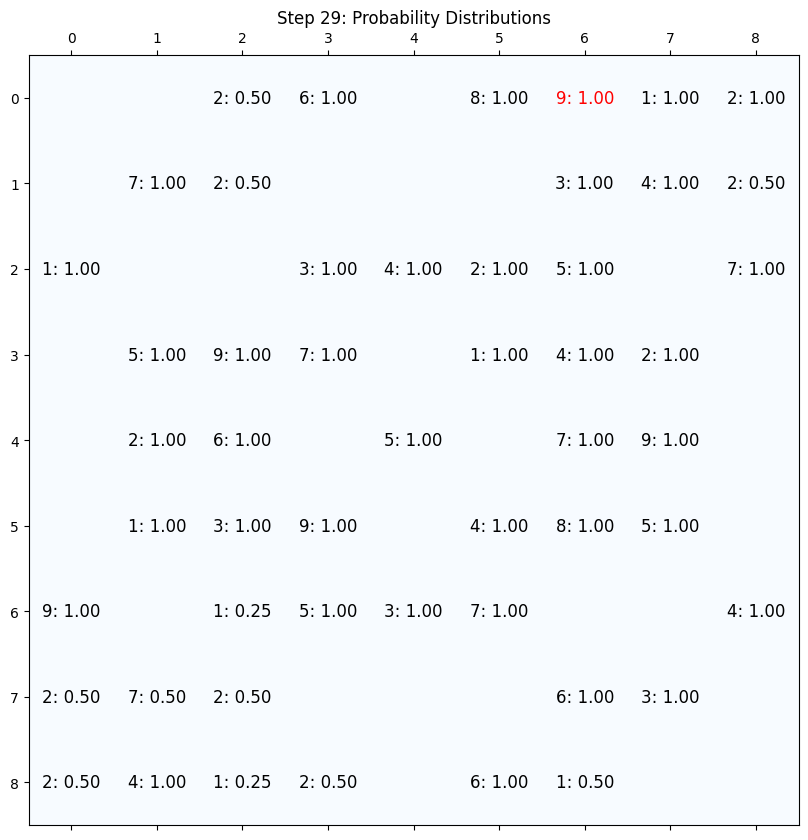

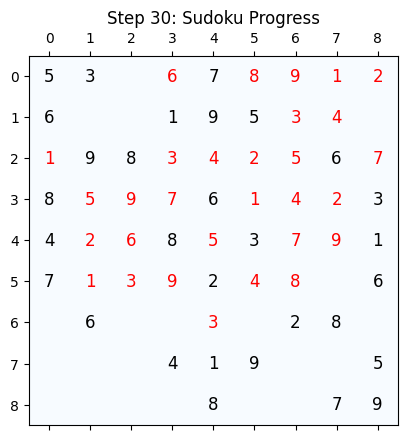

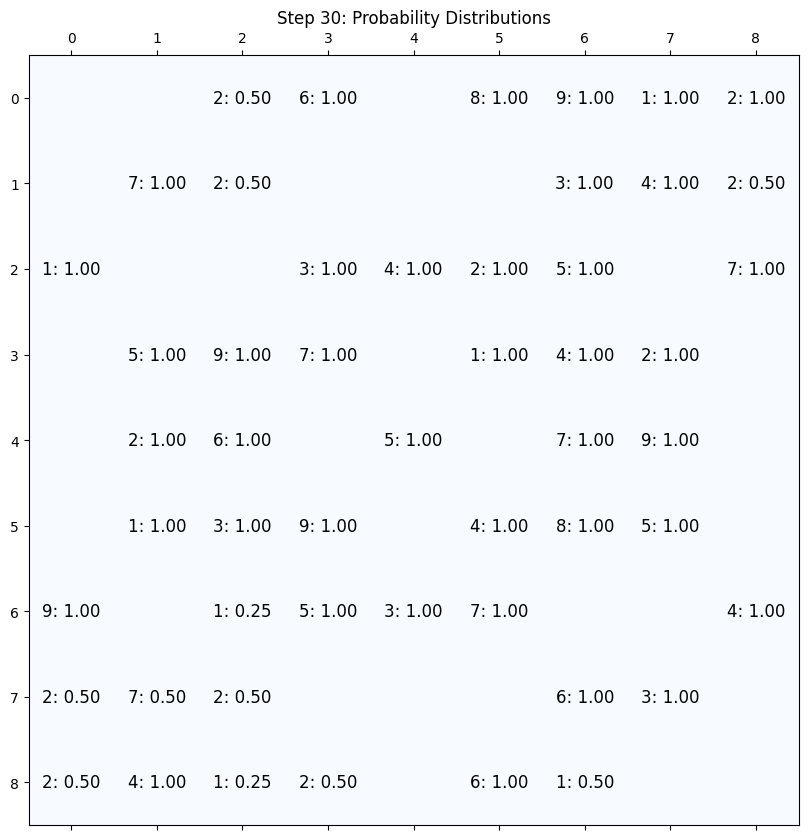

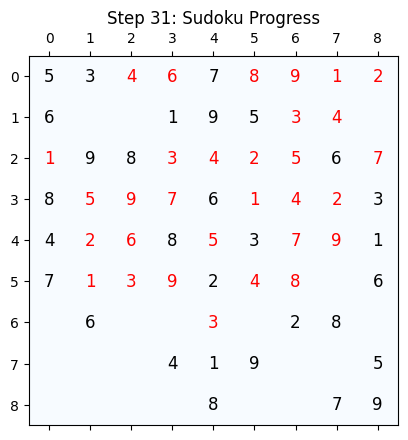

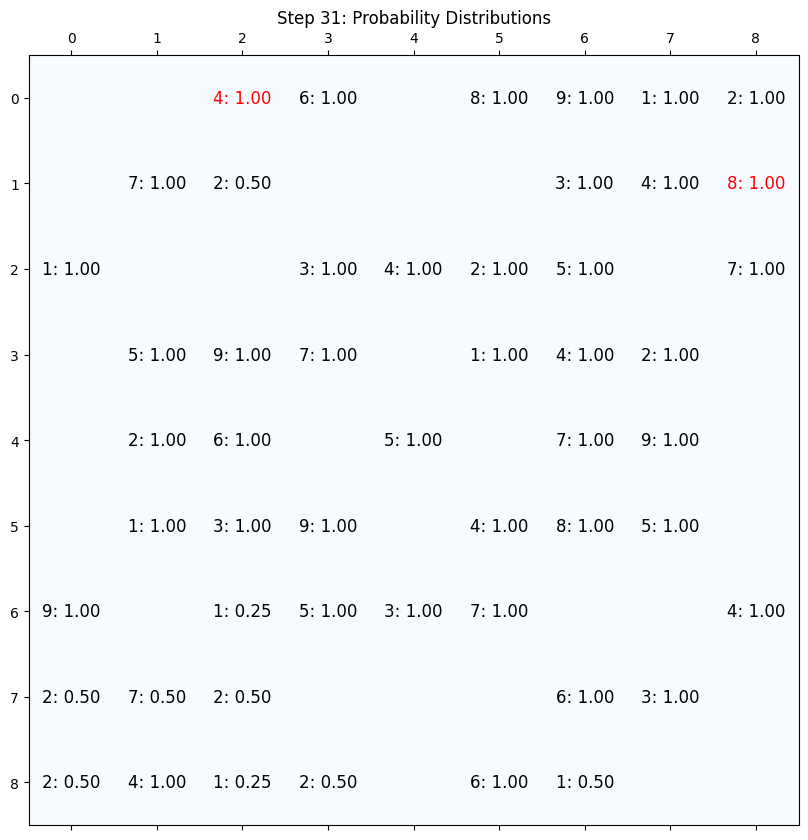

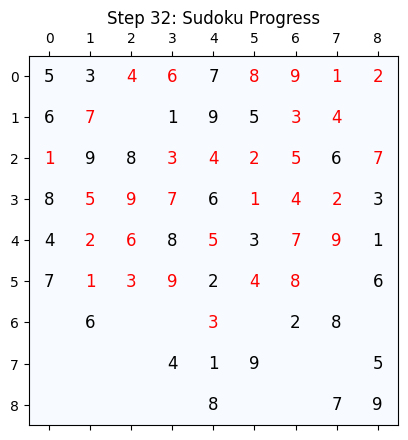

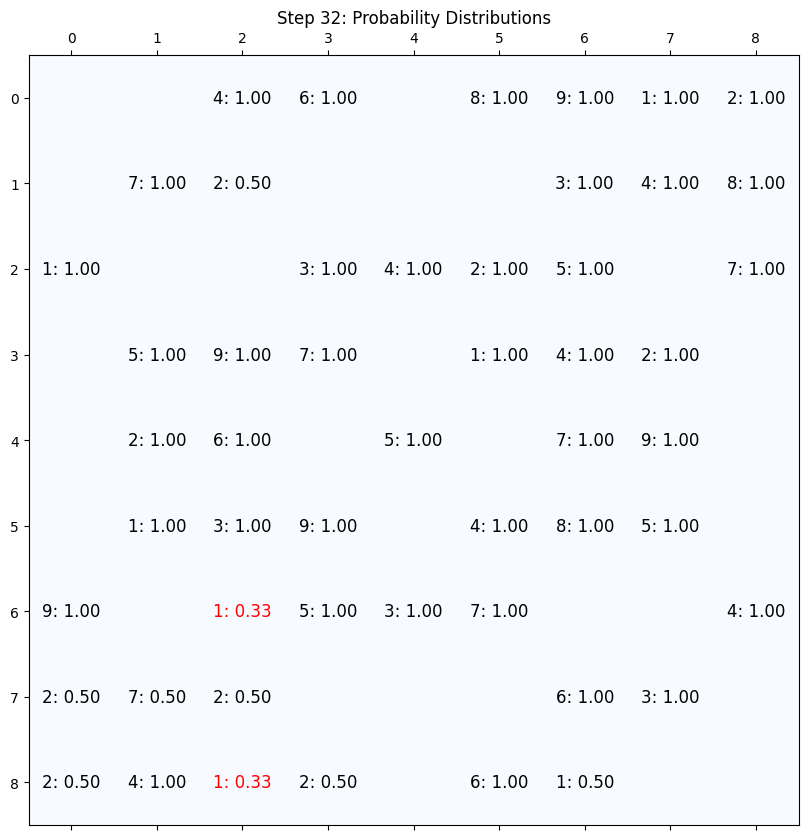

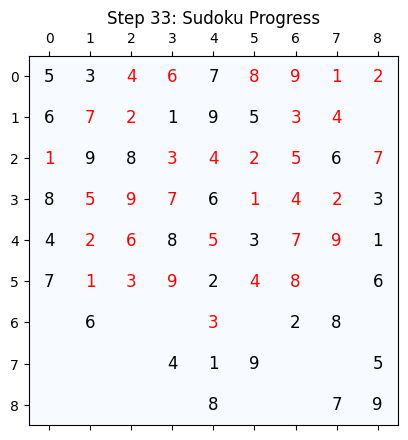

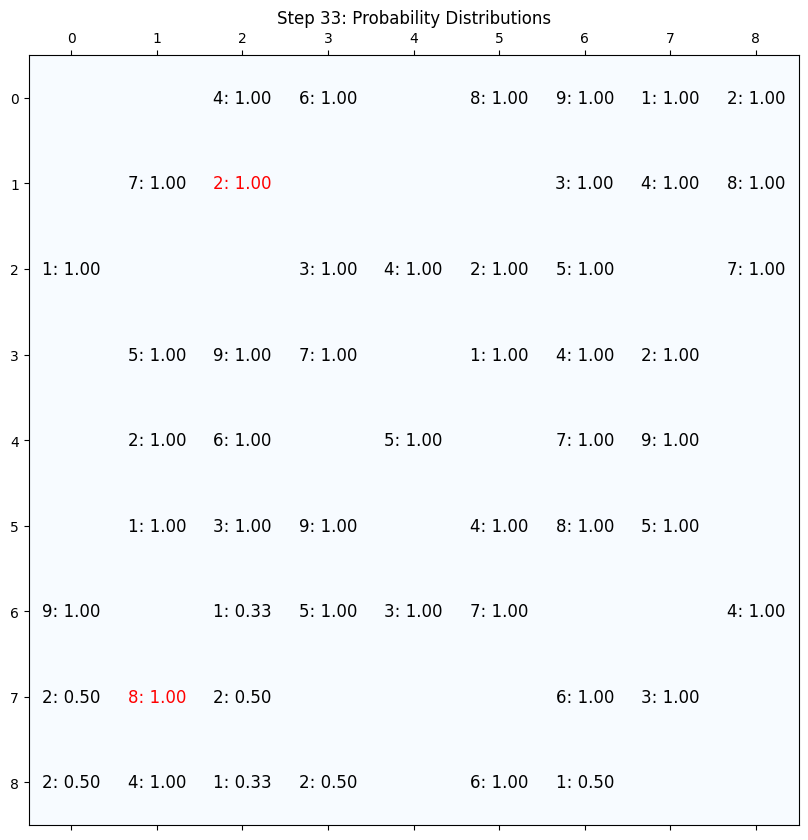

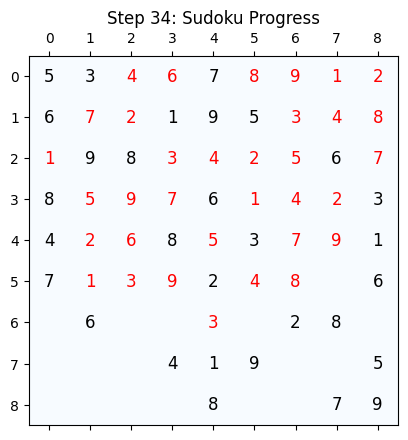

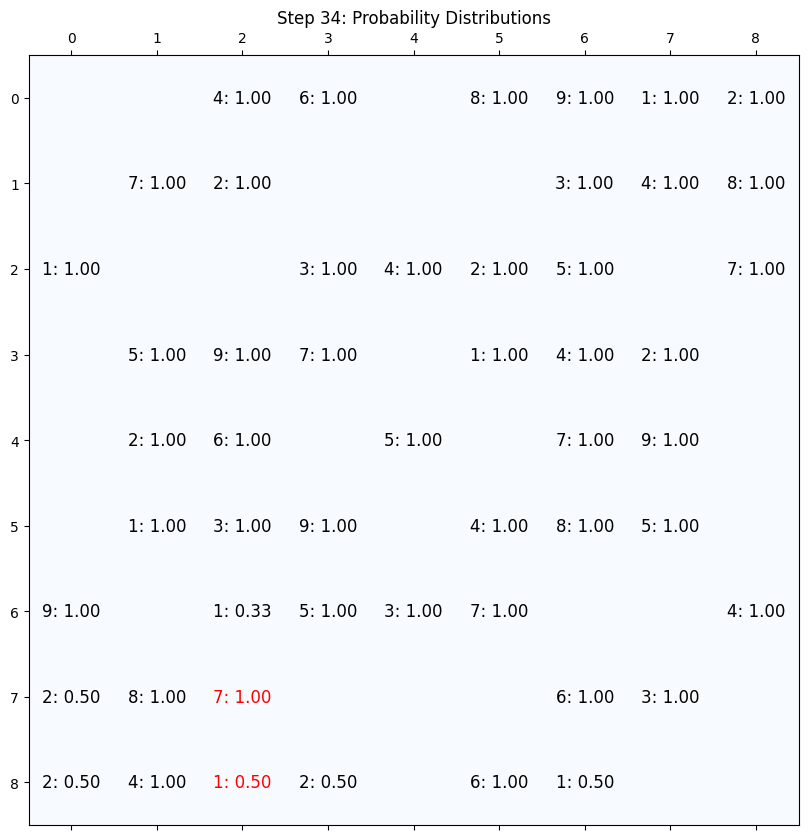

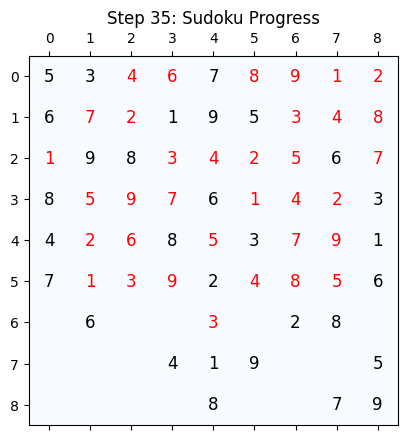

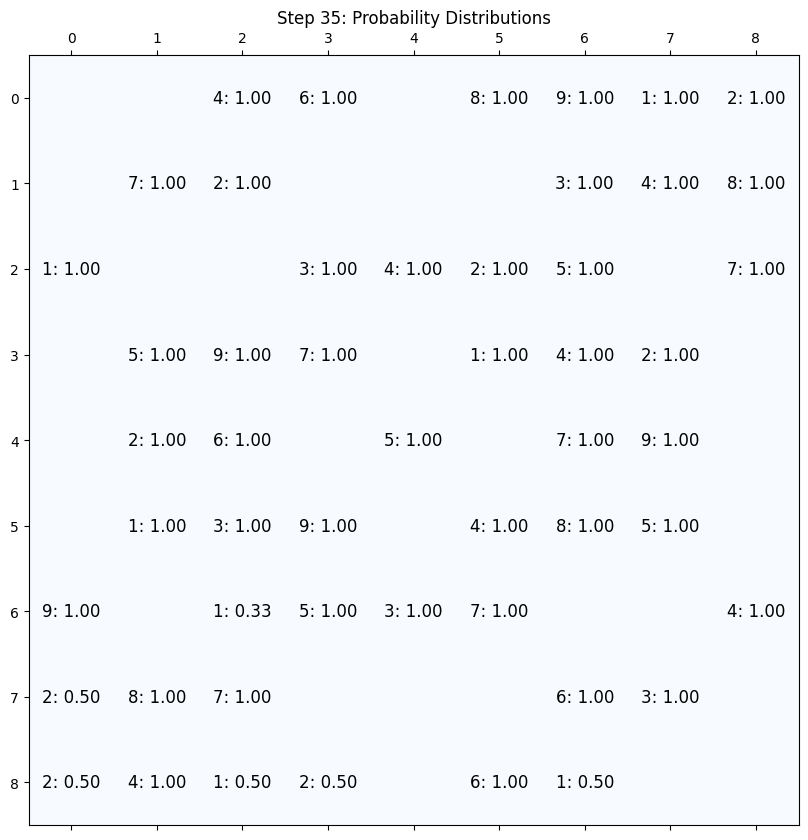

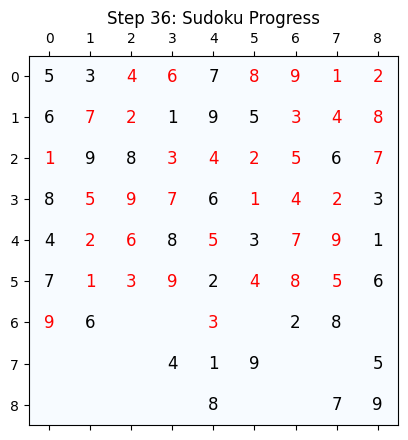

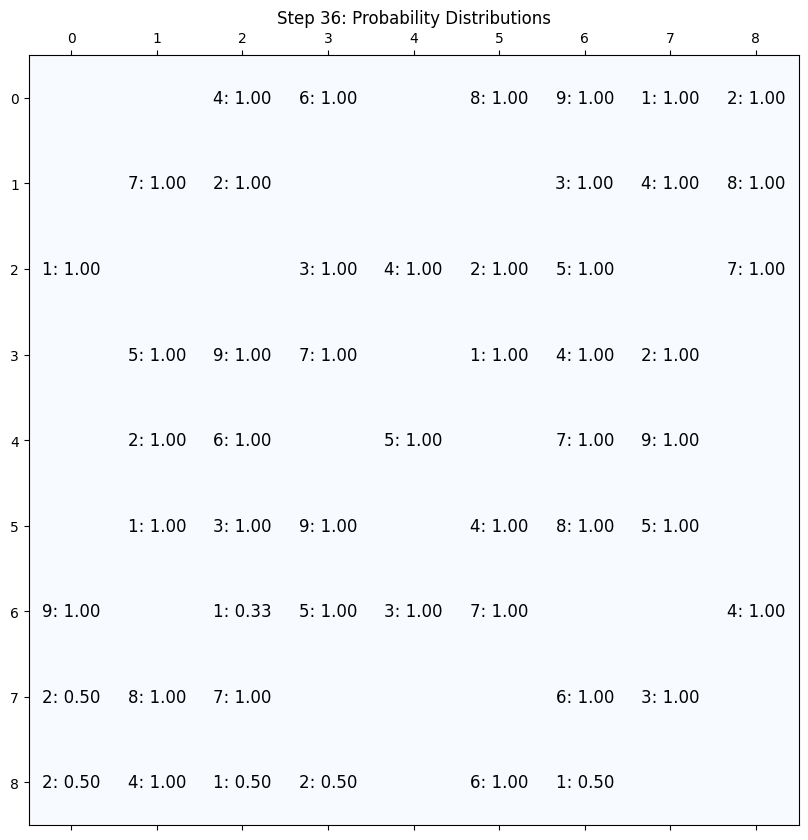

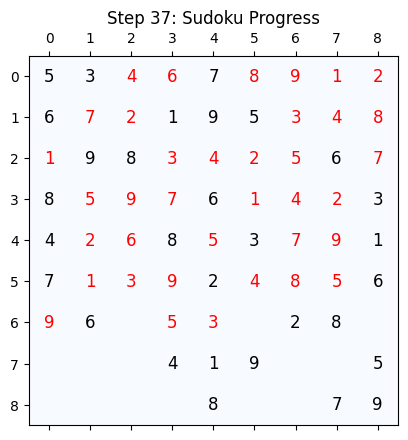

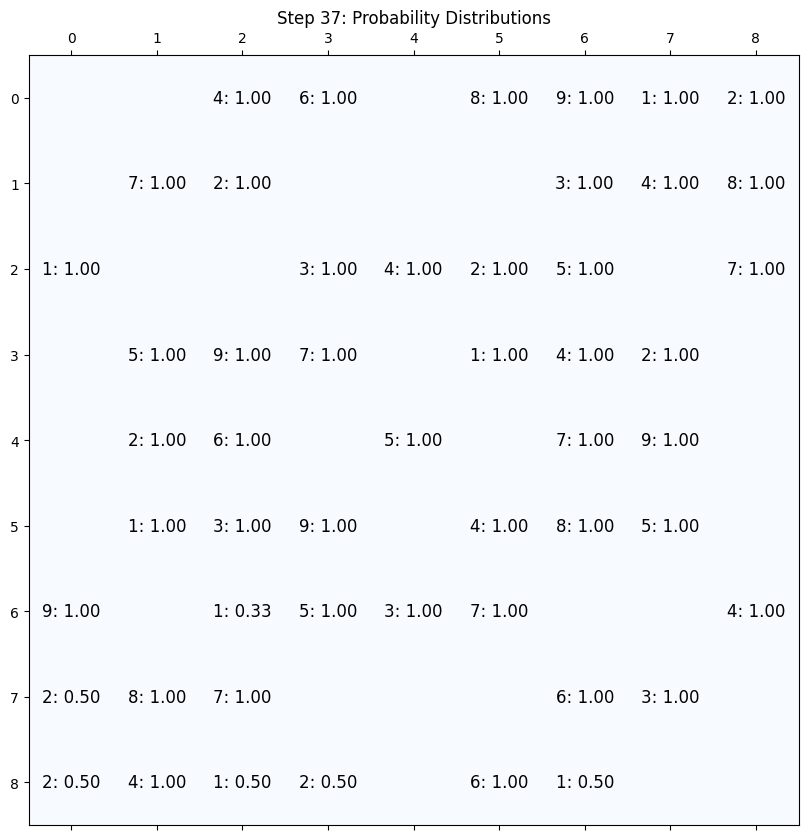

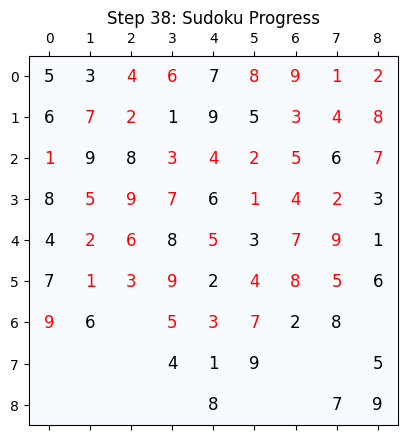

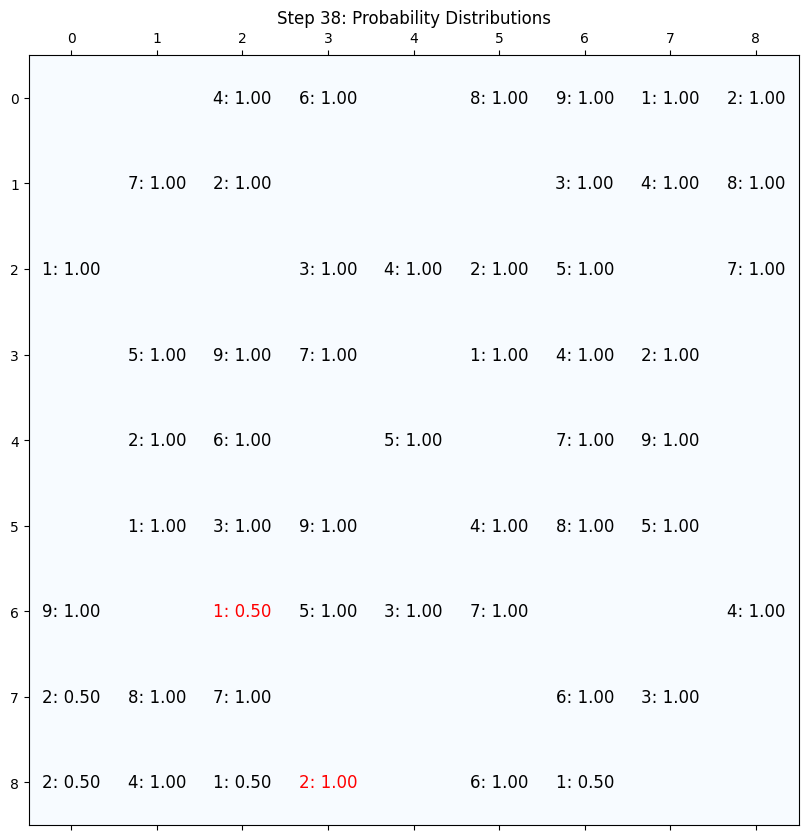

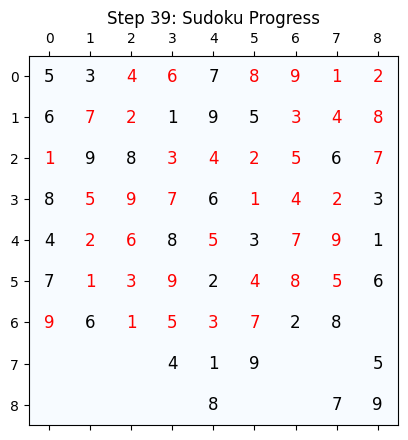

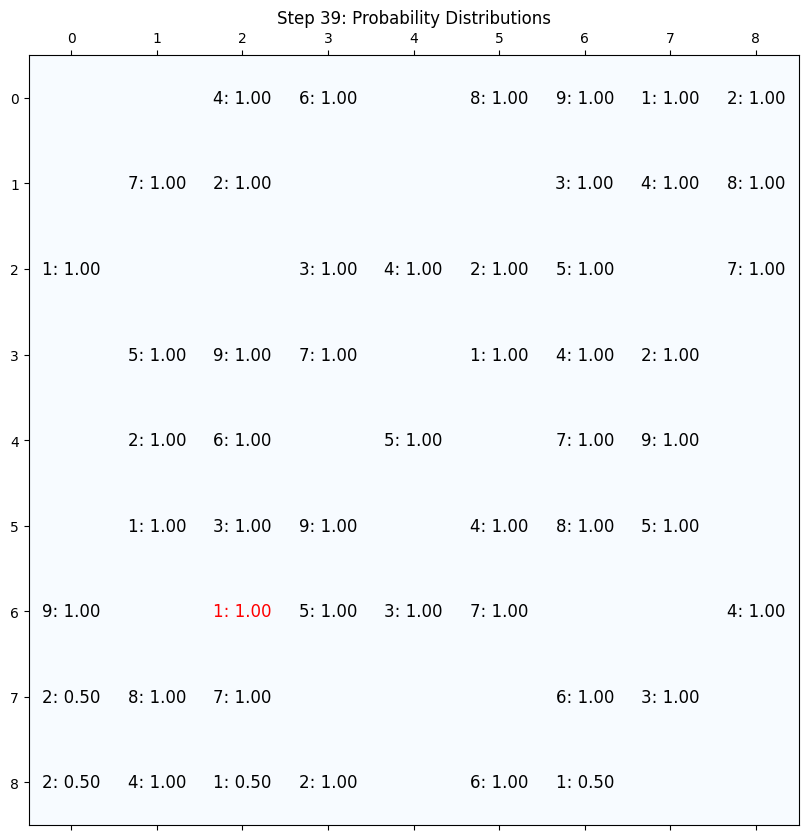

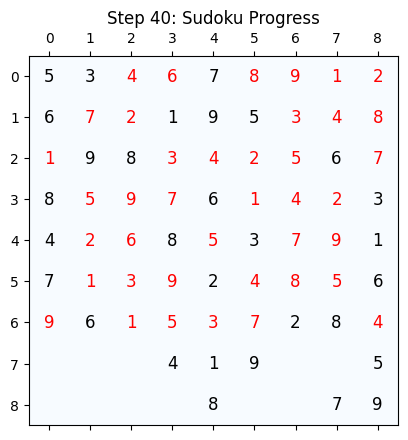

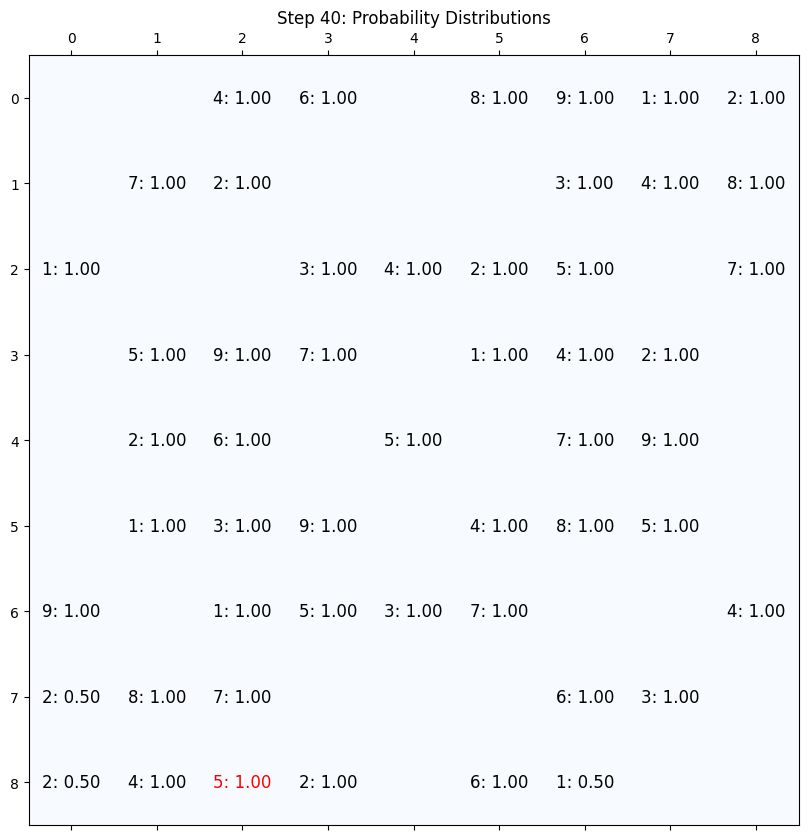

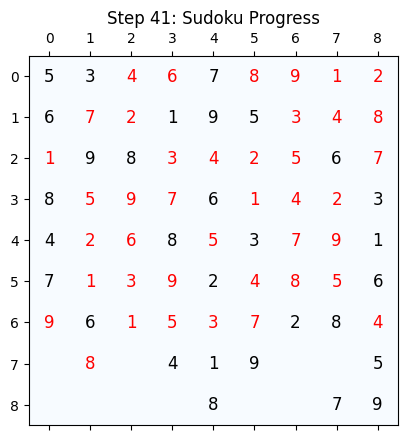

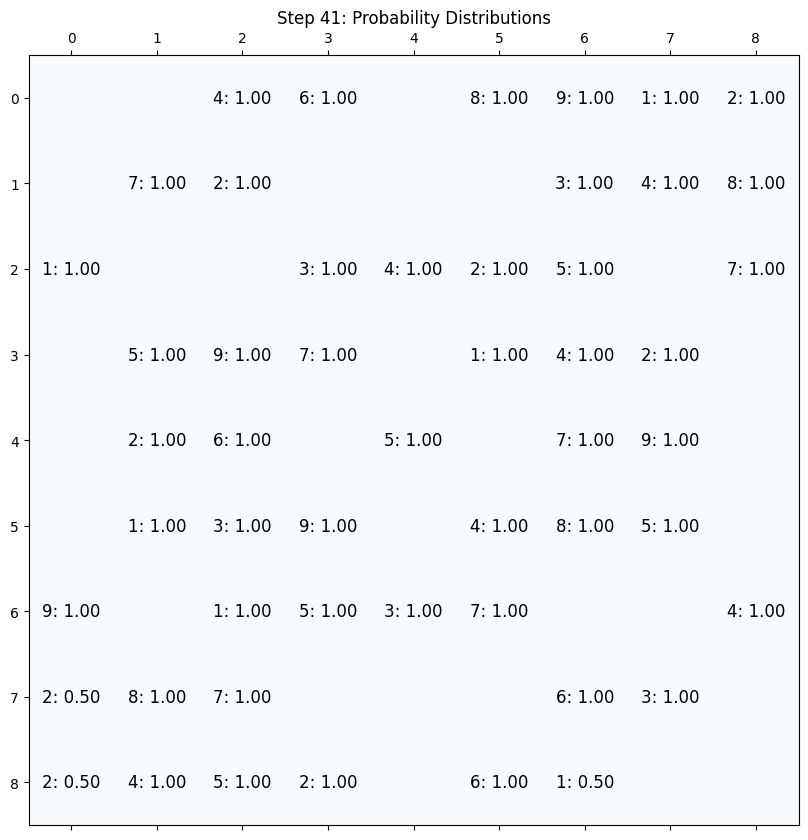

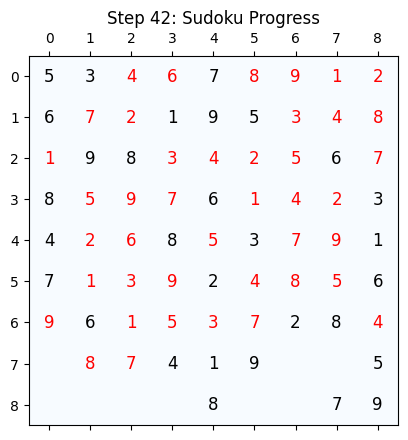

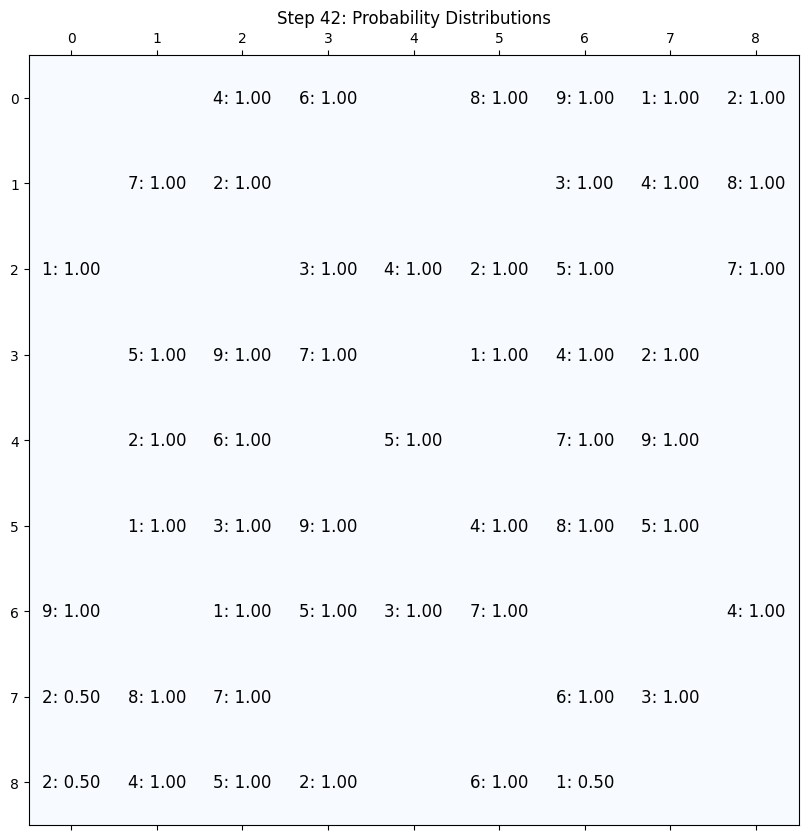

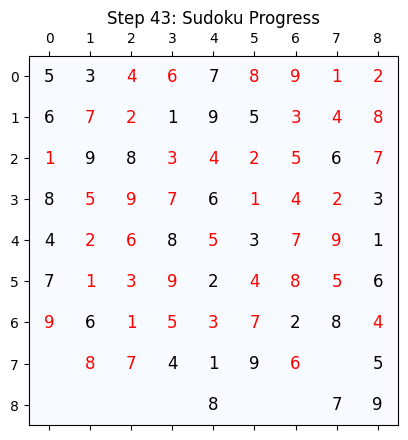

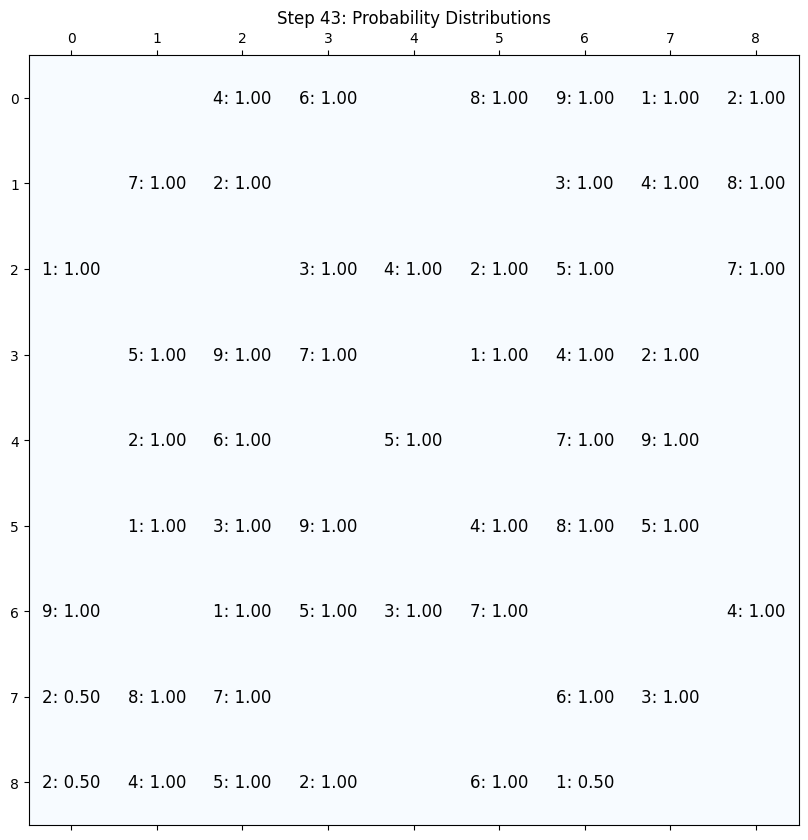

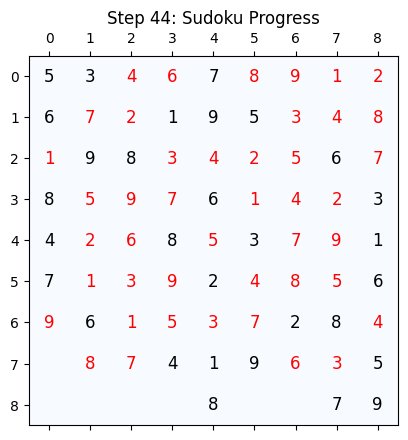

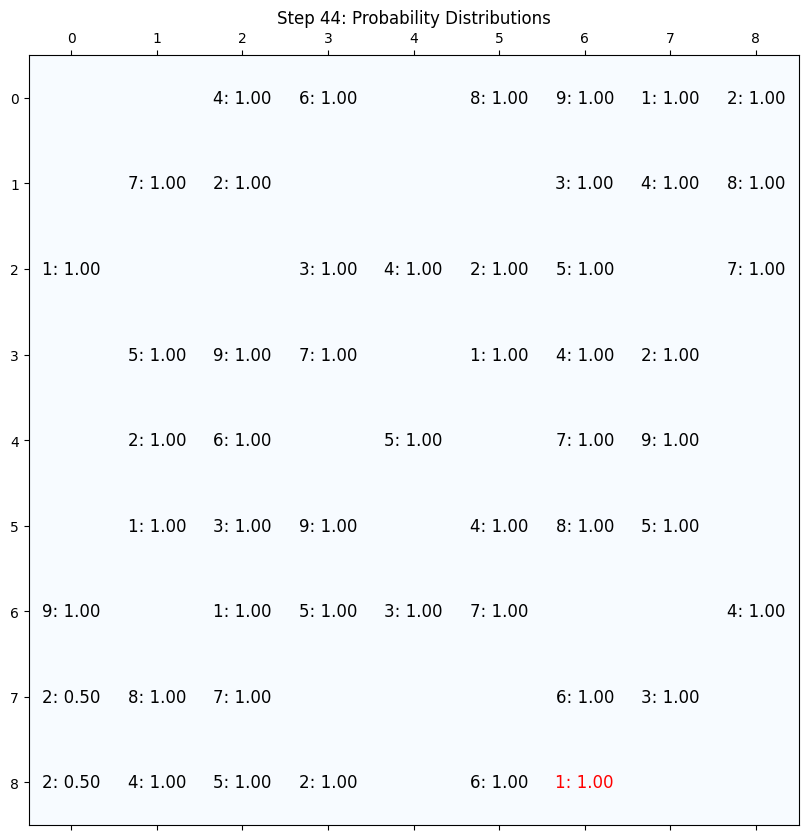

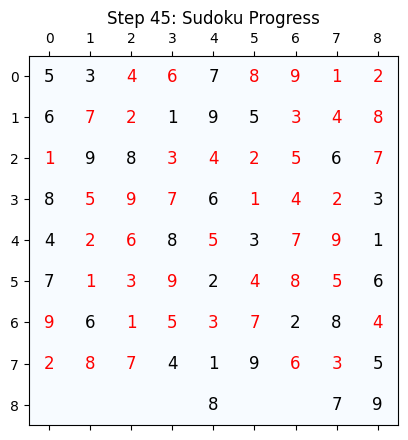

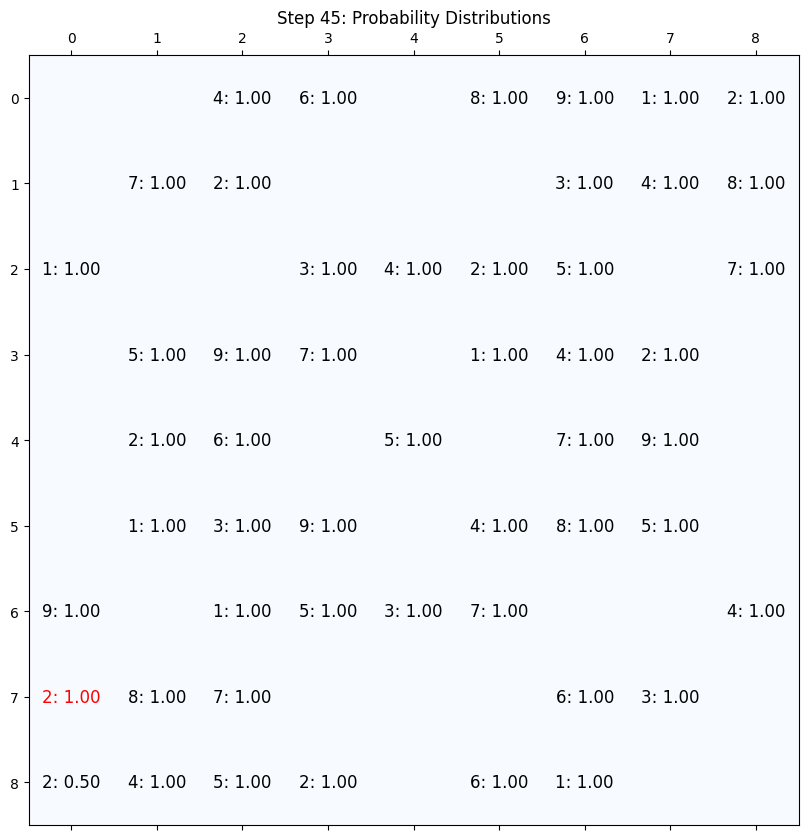

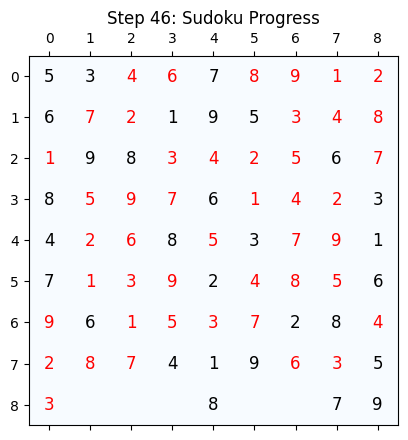

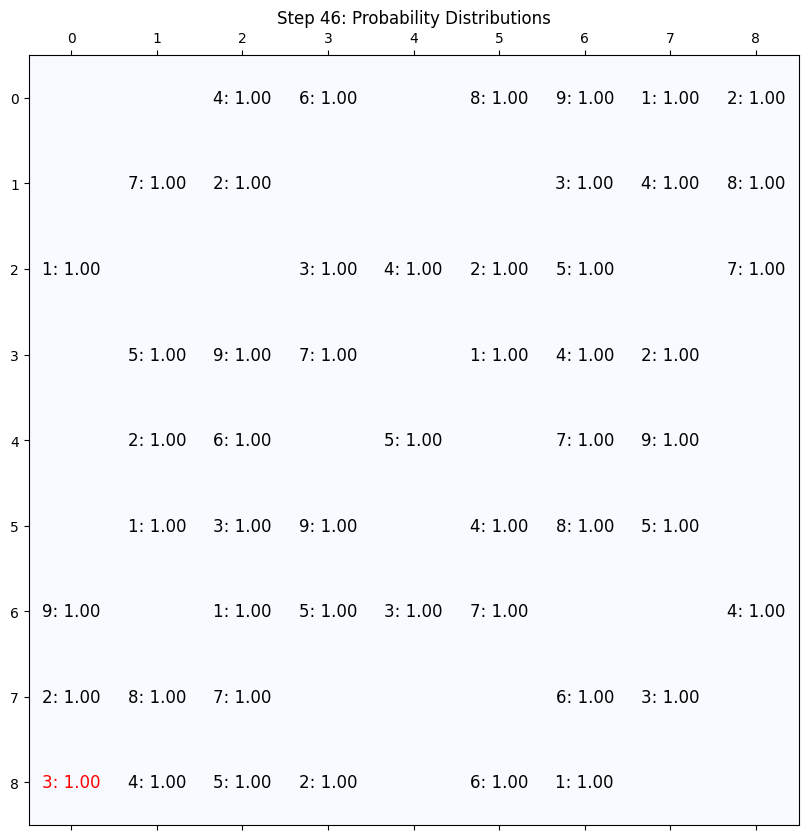

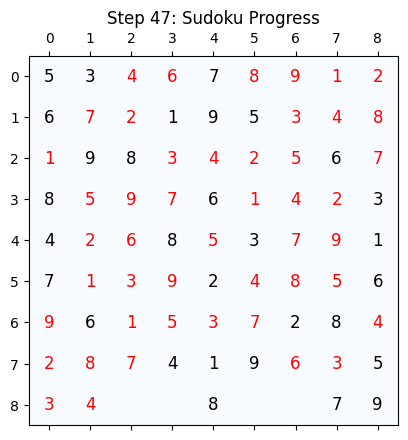

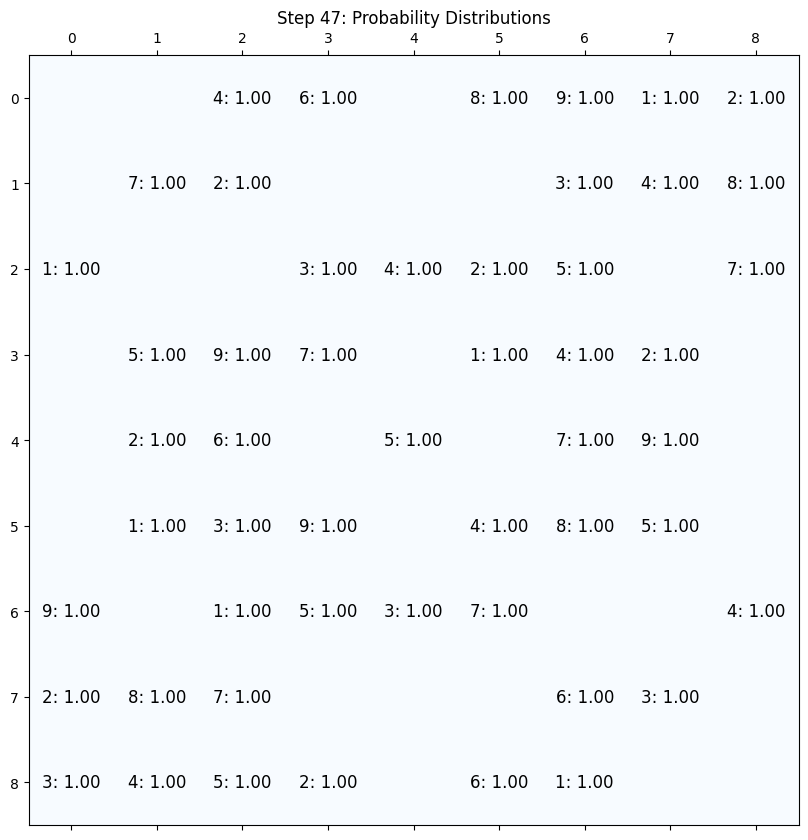

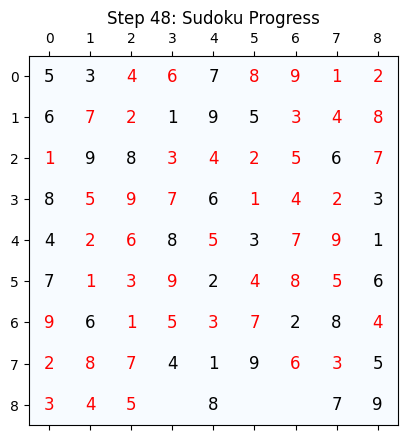

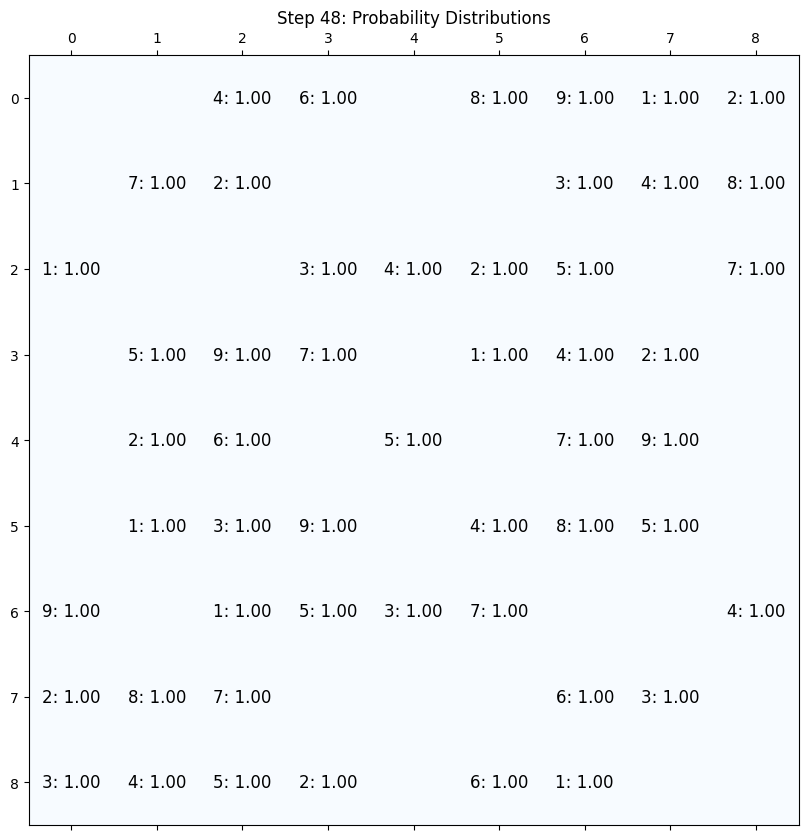

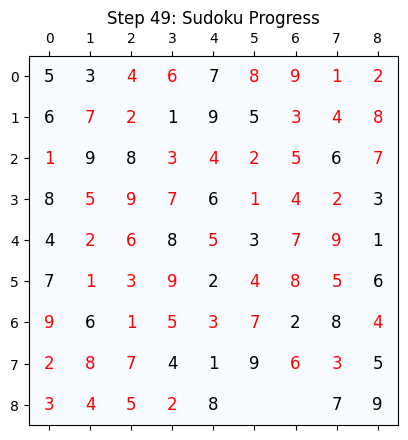

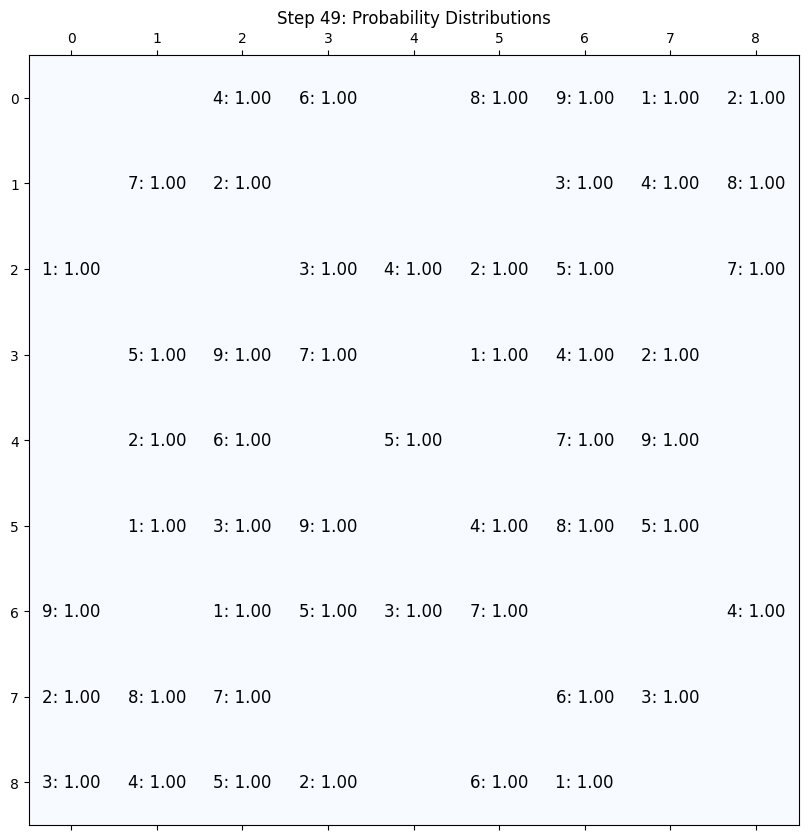

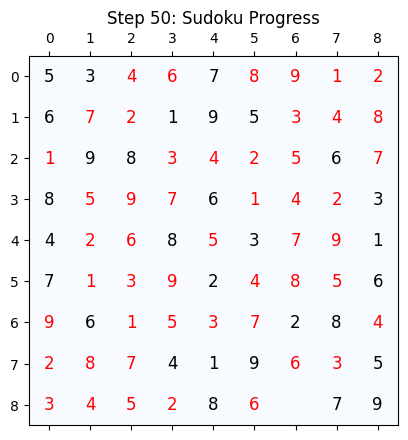

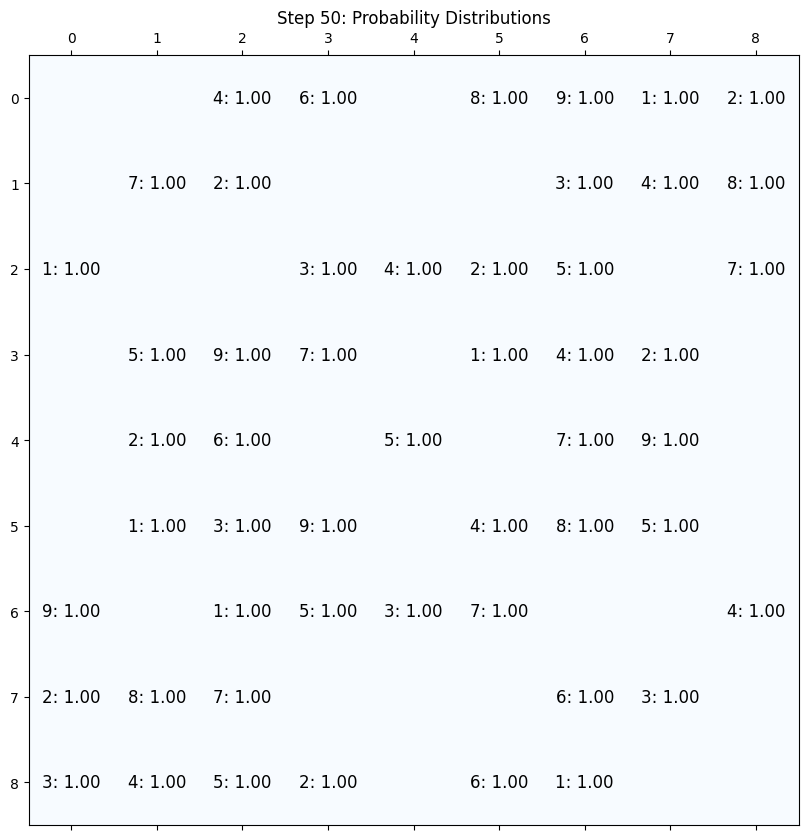

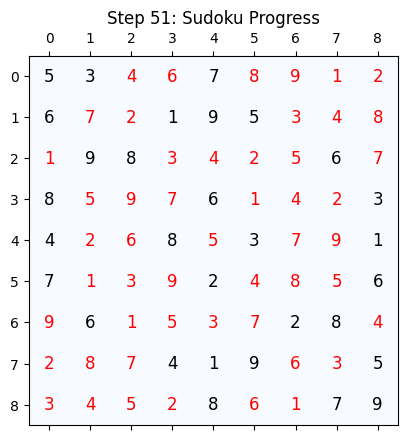

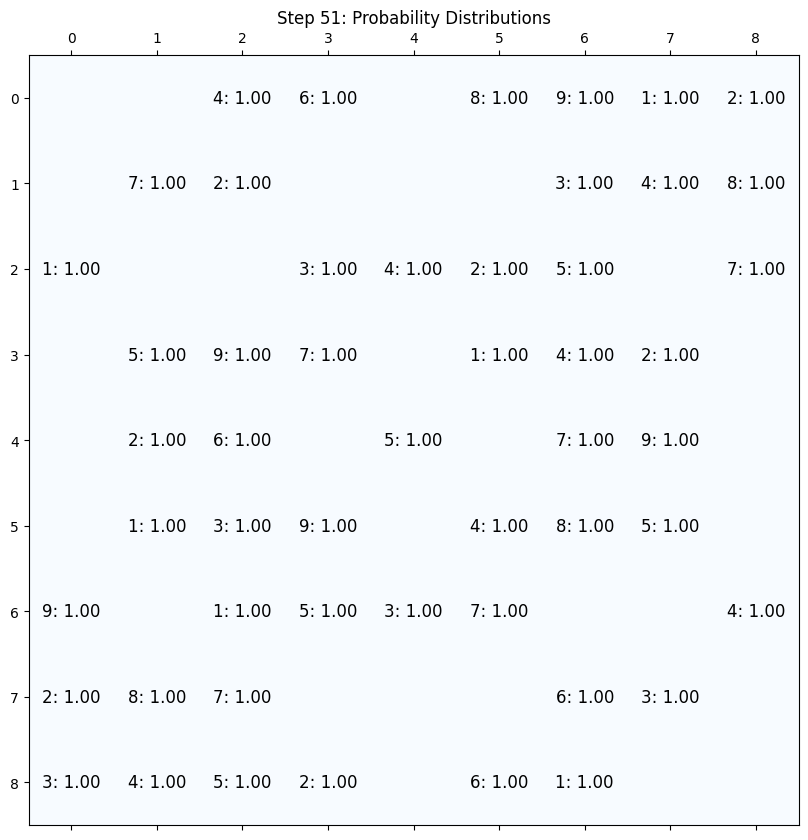

In [ ]:
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import copy

class SudokuCausalSolver:
    def __init__(self):
        # Initialize the 9x9 grid
        self.grid_size = 9
        self.box_size = 3
        self.grid = None

        # Prior probabilities for each cell (initially uniform)
        self.priors = {}

        # Conditional probability tables for constraints
        self.cpt = {}

    def initialize_grid(self, initial_grid):
        """Initialize the Sudoku grid with given values"""
        self.grid = np.array(initial_grid)

        # Initialize prior probabilities
        for i, j in product(range(self.grid_size), repeat=2):
            if self.grid[i][j] == 0:
                # If cell is empty, all numbers have equal probability
                self.priors[(i, j)] = np.ones(self.grid_size) / self.grid_size
            else:
                # If cell has a value, probability is 1 for that value
                self.priors[(i, j)] = np.zeros(self.grid_size)  # Initialize as zero array
                self.priors[(i, j)][self.grid[i][j] - 1] = 1.0  # Set probability for known value

    def update_conditional_probabilities(self):
        """Update conditional probability tables based on constraints"""
        for i, j in product(range(self.grid_size), repeat=2):
            if self.grid[i][j] == 0:
                # Get row constraints
                row_probs = self._get_row_probabilities(i)

                # Get column constraints
                col_probs = self._get_column_probabilities(j)

                # Get box constraints
                box_probs = self._get_box_probabilities(i - i % 3, j - j % 3)

                # Combine probabilities using Bayes' rule
                combined_probs = row_probs * col_probs * box_probs

                # Normalize probabilities
                if np.sum(combined_probs) > 0:
                    combined_probs = combined_probs / np.sum(combined_probs)

                self.cpt[(i,j)] = combined_probs

    def _get_row_probabilities(self, row):
        """Calculate probabilities based on row constraints"""
        probs = np.ones(self.grid_size)
        for j in range(self.grid_size):
            if self.grid[row][j] != 0:
                probs[self.grid[row][j]-1] = 0
        return probs if np.sum(probs) == 0 else probs / np.sum(probs)

    def _get_column_probabilities(self, col):
        """Calculate probabilities based on column constraints"""
        probs = np.ones(self.grid_size)
        for i in range(self.grid_size):
            if self.grid[i][col] != 0:
                probs[self.grid[i][col]-1] = 0
        return probs if np.sum(probs) == 0 else probs / np.sum(probs)

    def _get_box_probabilities(self, box_row, box_col):
        """Calculate probabilities based on 3x3 box constraints"""
        probs = np.ones(self.grid_size)
        for i, j in product(range(3), repeat=2):
            val = self.grid[box_row + i][box_col + j]
            if val != 0:
                probs[val-1] = 0
        return probs if np.sum(probs) == 0 else probs / np.sum(probs)

    def solve(self, max_iterations=100):
        """Solve the Sudoku puzzle using belief propagation"""
        iteration = 0
        snapshots = []  # Store snapshots of the grid for visualization
        probability_snapshots = []  # Store probability snapshots for each step
        while iteration < max_iterations:
            changed = False
            self.update_conditional_probabilities()

            # Find cell with highest probability
            max_prob = -1
            max_pos = None
            max_val = None

            for i, j in product(range(self.grid_size), repeat=2):
                if self.grid[i][j] == 0:
                    prob = np.max(self.cpt[(i,j)])
                    if prob > max_prob:
                        max_prob = prob
                        max_pos = (i,j)
                        max_val = np.argmax(self.cpt[(i,j)]) + 1

            # If we found a high probability cell, fill it
            if max_pos and max_prob > 0.9:  # Threshold for certainty
                self.grid[max_pos[0]][max_pos[1]] = max_val
                snapshots.append(copy.deepcopy(self.grid))  # Save the grid state
                probability_snapshots.append(copy.deepcopy(self.cpt))  # Save probabilities
                changed = True

            if not changed:
                break

            iteration += 1

        return self.grid, snapshots, probability_snapshots

# Drawing utilities
def print_grid(grid):
    """Print the grid with separators for 3x3 subgrids"""
    for i, row in enumerate(grid):
        if i % 3 == 0 and i != 0:
            print("-" * 21)
        row_str = ""
        for j, val in enumerate(row):
            if j % 3 == 0 and j != 0:
                row_str += "| "
            row_str += str(val) + " " if val != 0 else ". "
        print(row_str)

def plot_grid(grid, title, original_grid):
    """Visualize the Sudoku grid as an image with newly added numbers in red"""
    fig, ax = plt.subplots()
    ax.matshow(np.ones_like(grid) * -1, cmap="Blues")

    for i in range(9):
        for j in range(9):
            if grid[i][j] != 0:
                if original_grid[i][j] == 0 and grid[i][j] != 0:
                    ax.text(j, i, str(grid[i][j]), va='center', ha='center', color="red", fontsize=12)  # Newly added in red and larger
                else:
                    ax.text(j, i, str(grid[i][j]), va='center', ha='center', color="black", fontsize=12)  # Original in black
    plt.title(title)
    plt.show()

def plot_probabilities(probabilities, title, previous_probabilities):
    """Visualize the highest probability for each cell, with changes highlighted in red."""
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(np.ones((9, 9)) * -1, cmap="Blues")

    # Loop over all cells
    for (i, j), probs in probabilities.items():
        # Find the maximum probability for the current cell
        max_prob_index = np.argmax(probs)
        max_prob = probs[max_prob_index]

        # If there's no previous probability, draw the current highest probability in black
        if previous_probabilities is None:
            if max_prob > 0:  # Only display non-zero probabilities
                ax.text(j, i, f"{max_prob_index + 1}: {max_prob:.2f}", va='center', ha='center', fontsize=12, color="black")
        else:
            # If there's a previous probability, check if it has changed
            previous_max_prob = previous_probabilities[(i, j)][max_prob_index]

            if np.allclose(previous_max_prob, max_prob):
                # If the probability hasn't changed, draw it in black
                if max_prob > 0:
                    ax.text(j, i, f"{max_prob_index + 1}: {max_prob:.2f}", va='center', ha='center', fontsize=12, color="black")
            else:
                # If the probability has changed, draw it in red
                if max_prob > 0:
                    ax.text(j, i, f"{max_prob_index + 1}: {max_prob:.2f}", va='center', ha='center', fontsize=12, color="red")

    plt.title(title)
    plt.show()


# Example Sudoku puzzle (0 represents empty cells)
initial_grid = [
    [5,3,0,0,7,0,0,0,0],
    [6,0,0,1,9,5,0,0,0],
    [0,9,8,0,0,0,0,6,0],
    [8,0,0,0,6,0,0,0,3],
    [4,0,0,8,0,3,0,0,1],
    [7,0,0,0,2,0,0,0,6],
    [0,6,0,0,0,0,2,8,0],
    [0,0,0,4,1,9,0,0,5],
    [0,0,0,0,8,0,0,7,9]
]

# Create solver and solve
solver = SudokuCausalSolver()
solver.initialize_grid(initial_grid)
solution, snapshots, probability_snapshots = solver.solve()

# Display initial grid
print("Initial grid:")
print_grid(initial_grid)

# Display final solved grid
print("\nSolved grid:")
print_grid(solution)

# Visualize intermediate steps with red for new numbers and probabilities
previous_probabilities = None
for idx, snapshot in enumerate(snapshots):
    plot_grid(snapshot, f"Step {idx + 1}: Sudoku Progress", initial_grid)
    plot_probabilities(probability_snapshots[idx], f"Step {idx + 1}: Probability Distributions", previous_probabilities)
    previous_probabilities = probability_snapshots[idx]

## Discussion Questions (10 mins):

1. *Conceptual Understanding*. (5 mins)  
"In traditional Sudoku solving, we use deterministic constraints (a number either can or cannot go in a cell). In this causal net approach, we use probabilities instead. How does this difference reflect the broader distinction between Constraint Satisfaction Problems (CSPs) and Bayesian networks? What are the advantages and disadvantages of each approach?"
   
2. *Application and Analysis*. (5 mins)  
"The code uses a threshold of **0.9** probability to decide when to fill in a cell. How might changing this threshold affect the solver's behavior? Consider this in terms of the tradeoff between:    

 *   The risk of **making incorrect assignments** (Type I errors)
 *   The risk of **failing to make correct assignments** (Type II errors)   

 How does this relate to the concept of 'soft constraints' discussed in the lecture notes?"